# Entrega 1 - Clustering

**Enunciado:** 

Una empresa de helados llamada ``La Vía Láctea`` quiere hacer una campaña de marketing para augmentar la cantidad de clientes. Para hacer esto ha contactado a un equipo de investigación de la prestigiosa universidad de Harvard. Pero no estaban disponibles... <br> Así que decidieron ponerse en contacto con LaSalle para pedir el estudio de mercado a los estudiantes del MUDS.

**Se os pide:** utiliza el dataset ``customer_data.csv`` para encontrar posibles agrupaciones de clientes y así saber cómo enfocar la campaña. Para hacer esto es necesario que se realicen los siguientes apartados:

1. EDA (2.5 p) <br>
    1.1 Variables numéricas (1.25 p) <br>
    1.2 Variables categóricas (1.25 p) <br>
2. Procesado inicial de los datos (1.5 p) <br>
    2.1 Correlaciones (0.75 p) <br>
    2.2 PCA (0.75 p) <br>
3. Clustering (5 p) <br>
    3.1 Agrupación jerárquica (1 p) <br>
    3.2 K-means (1 p) <br>
    3.3 DBSCAN (1 p) <br>
    3.4 Optics  (Opcional +0,5 p. extras) ->  El solamente se aplica si se tiene una nota superior a 5. <br>
4. Justificación decisiones (2 p) <br>
5. Conclusión (1 p) <br>

El equipo de marketing de ``La Vía Láctea´´ pide que como resultado se entregue un estudio (en formato Jupyter notebook) que explique detalladamente los hallazgos encontrados durante el estudio y que plante una propuesta de estrategia para abordar la campaña.
<br><br>


---

**Descripción los ejercicios:**


**1. EDA ``(2.5p)``**

En este apartado se tienen que estudiar los datos mediante gráficas (scatterplot, barplot, violinplot, pairplot, etc.) y tests (shapiro-wilk, anova, etc.). Se tiene que comentar lo que se está analizando, descubriendo y que decisiones se van a tomar en consecuencia.

El estudio estadístico tiene dos partes:
1) Estudio de variables numéricas ``(1.25p)``
2) Estudio de variables categóricas ``(1.25p)``

**2. Procesado inicial de los datos ``(1.5p)``**

En este apartado se tiene que elegir las variables que se van a utilizar para los modelos que se usarán posteriormente, se tiene que hacer selección de variables con estudio de correlaciónes ``(0.75p)`` y PCA ``(0.75p)``.

**3. Clustering ``(5p)``**

En este apartado se tienen que utilizar los algoritmos de clustering vistos en clase para hacer la agrupación de los datos.

Se va a pedir que uséis los siguientes modelos:
- Agrupación jerárquica ``(1p)``
- K-means ``(1p)``
- DBSCAN ``(1p)``
- Optics ``(Opcional +0,5p. extras)`` -> _El solamente se aplica si se tiene una nota superior a 5._

La justificación, comparación modelos y explicación del proceso aplicado para hacer el clustering vale ``2p``

**4. Conclusiones ``(1p)``**

Escribid un resumen de lo que se ha hecho y de las decisiones tomadas en cada apartado.
<br><br>



---

**Descripción del Dataset:**

El dataset contiene información sobre clientes de La Vía Láctea con las siguientes variables:

**Personas**

- **ID**: Identificador único del cliente
- **Year_Birth**: Año de nacimiento del cliente
- **Education**: Nivel educativo del cliente
- **Marital_Status**: Estado civil del cliente
- **Income**: Ingresos anuales del hogar del cliente
- **Kidhome**: Número de niños en el hogar del cliente
- **Teenhome**: Número de adolescentes en el hogar del cliente
- **Dt_Customer**: Fecha de alta del cliente en la empresa
- **Recency**: Número de días desde la última compra del cliente
- **Complain**: 1 si el cliente presentó una queja en los últimos 2 años, 0 en caso contrario

**Productos**

- **MntWines**: Importe gastado en vino en los últimos 2 años
- **MntFruits**: Importe gastado en frutas en los últimos 2 años
- **MntMeatProducts**: Importe gastado en productos cárnicos en los últimos 2 años
- **MntFishProducts**: Importe gastado en pescado en los últimos 2 años
- **MntSweetProducts**: Importe gastado en productos dulces en los últimos 2 años
- **MntGoldProds**: Importe gastado en productos de oro en los últimos 2 años

**Promociones**

- **NumDealsPurchases**: Número de compras realizadas con descuento
- **AcceptedCmp1**: 1 si el cliente aceptó la oferta en la 1.ª campaña, 0 en caso contrario
- **AcceptedCmp2**: 1 si el cliente aceptó la oferta en la 2.ª campaña, 0 en caso contrario
- **AcceptedCmp3**: 1 si el cliente aceptó la oferta en la 3.ª campaña, 0 en caso contrario
- **AcceptedCmp4**: 1 si el cliente aceptó la oferta en la 4.ª campaña, 0 en caso contrario
- **AcceptedCmp5**: 1 si el cliente aceptó la oferta en la 5.ª campaña, 0 en caso contrario
- **Response**: 1 si el cliente aceptó la oferta en la última campaña, 0 en caso contrario

**Canal / Lugar de compra**

- **NumWebPurchases**: Número de compras realizadas a través del sitio web de la empresa
- **NumCatalogPurchases**: Número de compras realizadas mediante catálogo
- **NumStorePurchases**: Número de compras realizadas directamente en tiendas físicas
- **NumWebVisitsMonth**: Número de visitas al sitio web de la empresa en el último mes

---

## 0. Imports y carga de datos

Se importan las librerías necesarias para el análisis exploratorio, el preprocesamiento de los datos y el clustering.

In [119]:
import pandas as pd  #Librería Pandas
import numpy as np   #Librería Numpy

#Librería Scipy
from scipy.cluster import hierarchy 
from scipy.cluster.hierarchy import fcluster,dendrogram, linkage 
import scipy.stats as stats 

#Librería Sklearn
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.decomposition import PCA 
from sklearn.metrics import silhouette_score, davies_bouldin_score 
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN, OPTICS 
from sklearn.neighbors import NearestNeighbors 

#Librería MatplotLib
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec 

#Librería Seaborn
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

#Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

Se utiliza pandas como objeto con la funcion read_csv para cargar el dataset, utilizando como separador el tabulador ya que las columnas están separadas con un tabulador.

In [3]:
dataset = pd.read_csv("customer_data.csv", sep='\t')

## 1. EDA (Análisis Exploratorio de Datos)

En el Análisis Exploratorio de los datos, haremos un estudio exaustivo de los mismos para entender en profundidad que contienen, cual es su distribución, cual es su tamaño, cual es el tipo de dato y todas las características posibles para entenderlos, y entender que decisiones tomar para el estudio de posibles agrupaciones de clientes.

### 1.0 Estudio de los datos

Se visualiza las 5 primeras filas del dataset.

In [4]:
dataset.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


Se visualiza las 5 últimas filas del dataset.

In [5]:
dataset.tail()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,...,7,0,0,0,0,0,0,3,11,1


Se visualiza el tamaño del dataset.

In [6]:
dataset.shape

(2240, 29)

Se visualiza el tipo dato por cada columna que tiene el dataset.

In [7]:
dataset.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

Se visualizan los distintos valores que tiene la variable ``Marital_Status_value``.

In [8]:
Marital_Status_value = dataset["Marital_Status"].value_counts()
print(f"Cantidad de valores únicos de \"Marital_Status\" \n\n{Marital_Status_value}")

Cantidad de valores únicos de "Marital_Status" 

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


Sumamos todos los valores de cada fila de la tabla.

In [9]:
Marital_Status_value.sum()

2240

Se visualizan los distintos valores que tiene la variable ``Education``.

In [10]:
education_values = dataset["Education"].value_counts()
print(f"Cantidad de valores únicos de \"Education\" \n\n{education_values}")

Cantidad de valores únicos de "Education" 

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


Sumamos todos los valores de cada fila de la tabla.

In [11]:
education_values.sum()

2240

Se verifica si las columnas contienen *nulls*. Para ello se creo un bucle for con el cual se recorren todas las columnas del dataset en el cual por cada columna se hace una sumatoria de los nulls si es que contiene alguno y se imprime.

In [12]:
for col in dataset.columns:
    null_counts: int = (dataset[col].isnull().sum()) 
    print(f"La columna \"{col}\" contiene {null_counts} nulls")

La columna "ID" contiene 0 nulls
La columna "Year_Birth" contiene 0 nulls
La columna "Education" contiene 0 nulls
La columna "Marital_Status" contiene 0 nulls
La columna "Income" contiene 24 nulls
La columna "Kidhome" contiene 0 nulls
La columna "Teenhome" contiene 0 nulls
La columna "Dt_Customer" contiene 0 nulls
La columna "Recency" contiene 0 nulls
La columna "MntWines" contiene 0 nulls
La columna "MntFruits" contiene 0 nulls
La columna "MntMeatProducts" contiene 0 nulls
La columna "MntFishProducts" contiene 0 nulls
La columna "MntSweetProducts" contiene 0 nulls
La columna "MntGoldProds" contiene 0 nulls
La columna "NumDealsPurchases" contiene 0 nulls
La columna "NumWebPurchases" contiene 0 nulls
La columna "NumCatalogPurchases" contiene 0 nulls
La columna "NumStorePurchases" contiene 0 nulls
La columna "NumWebVisitsMonth" contiene 0 nulls
La columna "AcceptedCmp3" contiene 0 nulls
La columna "AcceptedCmp4" contiene 0 nulls
La columna "AcceptedCmp5" contiene 0 nulls
La columna "Acce

En un primer vistazo se visualiza que la columna "Income" contiene 24 nulls.

Verificamos que no haya filas duplicadas en el dataset.

In [13]:
duplicados = dataset.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")
if duplicados > 0:
    print(f"Filas duplicadas por ID: {dataset.duplicated(subset=['ID']).sum()}")

Filas duplicadas: 0


A continuación separamos los datos entre las variables numéricas y las variables categóricas para poder estudiarlas mejor.

### 1.1 Variables Numéricas

Separamos las variables numéricas del dataset.

In [14]:
dataset_numerical = dataset.select_dtypes(include=[np.number])
print(f"Variables numéricas: {list(dataset_numerical.columns)}")

Variables numéricas: ['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


Verificamos si existen valores nulos.

In [15]:
for col in dataset_numerical.columns:
    null_counts: int = (dataset_numerical[col].isnull().sum()) 
    print(f"La columna \"{col}\" contiene {null_counts} nulls")

La columna "ID" contiene 0 nulls
La columna "Year_Birth" contiene 0 nulls
La columna "Income" contiene 24 nulls
La columna "Kidhome" contiene 0 nulls
La columna "Teenhome" contiene 0 nulls
La columna "Recency" contiene 0 nulls
La columna "MntWines" contiene 0 nulls
La columna "MntFruits" contiene 0 nulls
La columna "MntMeatProducts" contiene 0 nulls
La columna "MntFishProducts" contiene 0 nulls
La columna "MntSweetProducts" contiene 0 nulls
La columna "MntGoldProds" contiene 0 nulls
La columna "NumDealsPurchases" contiene 0 nulls
La columna "NumWebPurchases" contiene 0 nulls
La columna "NumCatalogPurchases" contiene 0 nulls
La columna "NumStorePurchases" contiene 0 nulls
La columna "NumWebVisitsMonth" contiene 0 nulls
La columna "AcceptedCmp3" contiene 0 nulls
La columna "AcceptedCmp4" contiene 0 nulls
La columna "AcceptedCmp5" contiene 0 nulls
La columna "AcceptedCmp1" contiene 0 nulls
La columna "AcceptedCmp2" contiene 0 nulls
La columna "Complain" contiene 0 nulls
La columna "Z_Cost

La columna "Income" contiene 24 nulls para ver que hacer con esta columna la analizamos con mayor profundidad.

In [16]:
filas_con_nulls = dataset[dataset['Income'].isnull()]
filas_con_nulls

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
10,1994,1983,Graduation,Married,NaN,1,0,15-11-2013,11,5,...,7,0,0,0,0,0,0,3,11,0
27,5255,1986,Graduation,Single,NaN,1,0,20-02-2013,19,5,...,1,0,0,0,0,0,0,3,11,0
43,7281,1959,PhD,Single,NaN,0,0,05-11-2013,80,81,...,2,0,0,0,0,0,0,3,11,0
48,7244,1951,Graduation,Single,NaN,2,1,01-01-2014,96,48,...,6,0,0,0,0,0,0,3,11,0
58,8557,1982,Graduation,Single,NaN,1,0,17-06-2013,57,11,...,6,0,0,0,0,0,0,3,11,0
71,10629,1973,2n Cycle,Married,NaN,1,0,14-09-2012,25,25,...,8,0,0,0,0,0,0,3,11,0
90,8996,1957,PhD,Married,NaN,2,1,19-11-2012,4,230,...,9,0,0,0,0,0,0,3,11,0
91,9235,1957,Graduation,Single,NaN,1,1,27-05-2014,45,7,...,7,0,0,0,0,0,0,3,11,0
92,5798,1973,Master,Together,NaN,0,0,23-11-2013,87,445,...,1,0,0,0,0,0,0,3,11,0
128,8268,1961,PhD,Married,NaN,0,1,11-07-2013,23,352,...,6,0,0,0,0,0,0,3,11,0


A simple viste no parece que los NaN sigan algun patrón específico, el año de nacimiento parece ser contar con una variación, así también como la columna Education, Marital_Status, Kidhome, Teenhome, Dt_Customer, Recency, MntWines entre otros. Para definir que hacer vamos a separar filas con y sin nulls en Income y compararlos para ver si encontramos algún patrón que no es visible.

In [17]:
con_income = dataset[dataset['Income'].notna()]
sin_income = dataset[dataset['Income'].isna()]

Comparamos por el tipo de educación.

In [18]:
print(f"Con Income:\n{con_income['Education'].value_counts(normalize=True).round(3)}")
print(f"\nSin Income:\n{sin_income['Education'].value_counts(normalize=True).round(3)}")

Con Income:
Education
Graduation    0.504
PhD           0.217
Master        0.165
2n Cycle      0.090
Basic         0.024
Name: proportion, dtype: float64

Sin Income:
Education
Graduation    0.458
PhD           0.208
Master        0.208
2n Cycle      0.125
Name: proportion, dtype: float64


No se visualiza un patrón fijo que haya en las filas que son NaN en comparación a las que si tienen. Continuamos la verificación con el tipo de Marital_Status.

In [19]:
print(f"Con Income:\n{con_income['Marital_Status'].value_counts(normalize=True).round(3)}")
print(f"\nSin Income:\n{sin_income['Marital_Status'].value_counts(normalize=True).round(3)}")

Con Income:
Marital_Status
Married     0.387
Together    0.259
Single      0.213
Divorced    0.105
Widow       0.034
Alone       0.001
Absurd      0.001
YOLO        0.001
Name: proportion, dtype: float64

Sin Income:
Marital_Status
Single      0.375
Married     0.292
Together    0.292
Widow       0.042
Name: proportion, dtype: float64


Tampoco se visualiza un patrón fijo que haya en las filas que son NaN en comparación a las que si tienen. Entonces comparamos promedios numéricos del dataset para entender si se debe por otra razón.

In [20]:
cols_comparar = ['Year_Birth', 'Kidhome', 'Teenhome', 'MntWines', 'Recency']
for col in cols_comparar:
    print(f"   {col}: Con Income = {con_income[col].mean():.2f} | Sin Income = {sin_income[col].mean():.2f}")

   Year_Birth: Con Income = 1968.82 | Sin Income = 1967.46
   Kidhome: Con Income = 0.44 | Sin Income = 0.67
   Teenhome: Con Income = 0.51 | Sin Income = 0.58
   MntWines: Con Income = 305.09 | Sin Income = 197.21
   Recency: Con Income = 49.01 | Sin Income = 58.04


Donde tampoco se visualiza un patrón claro en las filas que tienen NaNs, es decir no se encontró un patrón claro del porque están vacias. Seguiremos analizando visualizando los incomes promedios por educación y marital status y cruzar ambas variables, para seguir viendo patrones en Income y poder decidir como tratar estos valores nulls.

Visualizamos el Income promedio por Education.

In [21]:
print(dataset.groupby('Education')['Income'].agg(['mean', 'median', 'count']).round(2))

                mean   median  count
Education                           
2n Cycle    47633.19  46805.0    200
Basic       20306.26  20744.0     54
Graduation  52720.37  52028.5   1116
Master      52917.53  50943.0    365
PhD         56145.31  55212.0    481


Se ve una diferencia clara en el Income entre el grupo que su Education es Basic y 2n Cycle y los de educación superior, aunque también se visualiza que la proporción de datos no es la misma en todos los grupos, es bastante variable. Para seguir analizando visualizamos el Income promedio por Marital_status.

In [22]:
print(dataset.groupby('Marital_Status')['Income'].agg(['mean', 'median', 'count']).round(2))

                    mean   median  count
Marital_Status                          
Absurd          72365.50  72365.5      2
Alone           43789.00  35860.0      3
Divorced        52834.23  52683.0    232
Married         51724.98  51876.0    857
Single          50995.35  48904.0    471
Together        53245.53  51369.0    573
Widow           56481.55  56551.0     76
YOLO            48432.00  48432.0      2


En Marital_status la variabilidad en los grupos es menor a excepción de Absurd que tiene una media y mediana mucho más superior pero su muestra solo tiene dos datos, así que tampoco es significativa y en los grupos con distribución mayor que son Married, Single, Together y Divorced el Income es similar no tiene una varianza muy grande. Ahora visualizamos un cruce entre las variables Education y Marital_status para ver si siguen un patrón juntas.

In [23]:
print(dataset.pivot_table(values='Income', index='Education', columns='Marital_Status', aggfunc='median').round(0))

Marital_Status   Absurd    Alone  Divorced  Married   Single  Together  \
Education                                                                
2n Cycle            NaN      NaN   49118.0  46462.0  48668.0   45774.0   
Basic               NaN      NaN    9548.0  22352.0  16383.0   23179.0   
Graduation      79244.0  34176.0   55635.0  50737.0  49974.0   53977.0   
Master          65487.0  61331.0   49476.0  53088.0  49494.0   49736.0   
PhD                 NaN  35860.0   50614.0  57082.0  50198.0   56756.0   

Marital_Status    Widow     YOLO  
Education                         
2n Cycle        47682.0      NaN  
Basic           22123.0      NaN  
Graduation      58275.0      NaN  
Master          51529.0      NaN  
PhD             57032.0  48432.0  


Se visualiza que en Basic hay un Income menor, donde hay NaNs en Absurd, Alone y YOLO. Luego 2n Cycle con Nan en Absurd, Alone y YOLO es el 2do grupo con menor Income. Lo que se verifica es que hay un patrón en el nivel educativo y el Income de los clientes. Lo cual podría ser interesante, es decir podríamos llenar los nulls tomando la mediana por grupo que corresponda, pero antes de tomar una decisión analizaremos Income con respecto a las variables numéricas también.

Para ello creamos la variable Age para que sea más intuitivo.

In [24]:
dataset['Age'] = 2024 - dataset['Year_Birth']

Correlacionamos el Income con las variables numéricas del dataset.

In [25]:
correlaciones = dataset[['Income', 'Age', 'Kidhome', 'Teenhome', 'Recency','MntWines', 'MntMeatProducts', 'NumStorePurchases']].corr()['Income'].sort_values(ascending=False)
print(correlaciones.round(3))

Income               1.000
MntMeatProducts      0.585
MntWines             0.579
NumStorePurchases    0.529
Age                  0.162
Teenhome             0.019
Recency             -0.004
Kidhome             -0.429
Name: Income, dtype: float64


Donde Kidhome presenta una correlación negativa con Income, lo que significa que: mientras más hijos en casa, menos Income reportado y mientras menos hijos en casa más Income reportado. Teniendo en cuenta también el patrón que vimos en cuanto al nivel educativo y el Income, a continuación hago una gráfica de barras para visualizar la mediana de Income por Education y Kidhome.

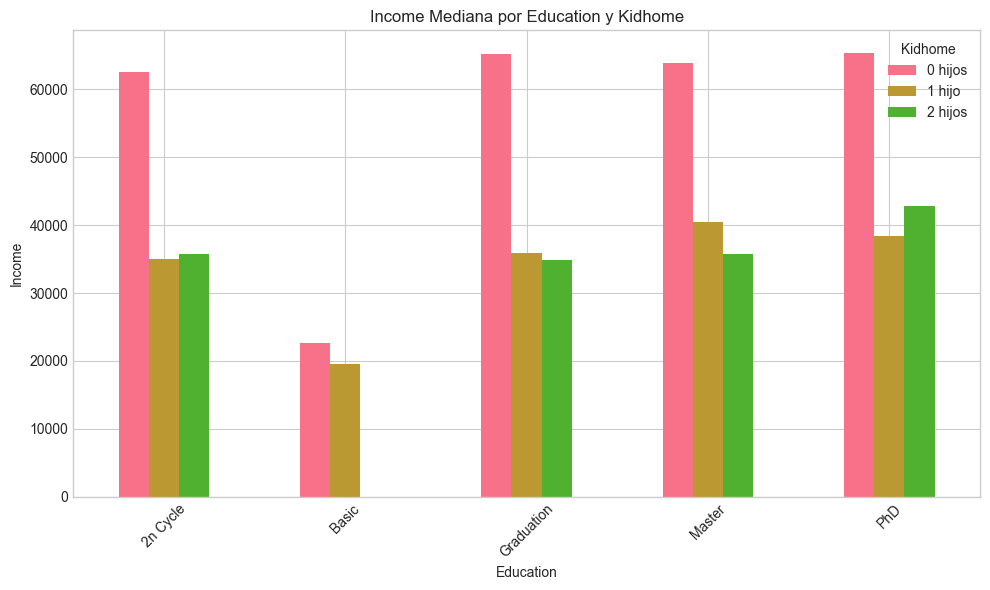

In [26]:
tabla_median = dataset.pivot_table(values='Income', index='Education', columns='Kidhome', aggfunc='median')
tabla_median.plot(kind='bar', figsize=(10, 6))
plt.title('Income Mediana por Education y Kidhome')
plt.xlabel('Education')
plt.ylabel('Income')
plt.legend(title='Kidhome', labels=['0 hijos', '1 hijo', '2 hijos'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Donde claramente se ve como la cantidad de hijos afecta el income, y en cuanto a la educación afecta mucho más a la educación básica que a otras lo cual podría ser interesante, ya que teniendo en cuenta esta agrupación podríamos llenar los nulls con una mediana por grupo para no perder a estos clientes en el análisis.

Antes de descartar otros análisis, analizamos el Income promedio por rangos de edad.

In [27]:
dataset['Age_Group'] = pd.cut(dataset['Age'], bins=[20, 35, 50, 65, 100], labels=['20-35', '36-50', '51-65', '65+'])
print(dataset.groupby('Age_Group')['Income'].agg(['median', 'count']).round(0))

            median  count
Age_Group                
20-35      42680.0     90
36-50      42386.0    751
51-65      52531.0    863
65+        58821.0    509


Donde hay una diferencia en los grupos, pero tampoco es demasiado significativa, como si se presenta en el caso de la educación y cantidad de niños en la casa. Para terminar de analizar el Income hacemos un cruce de la mediana del Income por Education y Edad.

In [28]:
print(dataset.pivot_table(values='Income', index='Education', columns='Age_Group', aggfunc='median').round(0))

Age_Group     20-35    36-50    51-65      65+
Education                                     
2n Cycle    55155.0  35684.0  49726.0  62972.0
Basic       17372.0  20425.0  22634.0  21026.0
Graduation  44399.0  44322.0  54188.0  58398.0
Master      89529.0  43263.0  49505.0  58656.0
PhD         68404.0  50150.0  54111.0  59292.0


Se visualiza una diferencia significativa más en la educación que en los rangos de edad como tal, y especificamente en la educación básica a comparación de las otras.

En este análisis se vió una mayor influencia en el Income en el nivel educativo específicamente si la educación es básica o no y en la cantidad de niños que hay en el hogar como se visualiza en el gráfico de barras graficado. Por ello se decidió rellenar los valores nulos con la mediana del Income agrupado por la educación y la cantidad de niños que hay en casa. La decisión tiene importancia ya que la idea de este problema es agrupar a los clientes no eliminarlos. 

In [29]:
print(f"Nulls antes: {dataset['Income'].isnull().sum()}")
dataset['Income'] = dataset.groupby(['Education', 'Kidhome'])['Income'].transform(lambda x: x.fillna(x.median()))
print(f"Nulls después: {dataset['Income'].isnull().sum()}")

Nulls antes: 24
Nulls después: 0


Agregamos Age al dataset numerico.

In [30]:
dataset_numerical['Age'] = dataset['Age']

##### **1.1.1 Histogramas**

A continuación nos interesa analizar la distribución de las variables numéricas. Teniendo en cuenta que en la descripción se explica las columas correspondientes a las personas, a los productos, a los canales creamos distintas variables para a la hora de analizar poder entender y explicar mejor las mismas. También se han encontrado variables binarias que se explicaran su distribución a continuación mediante gráficos de barras.

In [31]:
personas_continuas = ['Income', 'Age', 'Recency']
personas_discretas = ['Kidhome', 'Teenhome']
productos = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
canales = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'NumDealsPurchases']
binarias = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response', 'Complain']

De estos grupos se han exlcuido el ID (el identificador) y Z_CostContact, Z_Revenue (valores constantes).

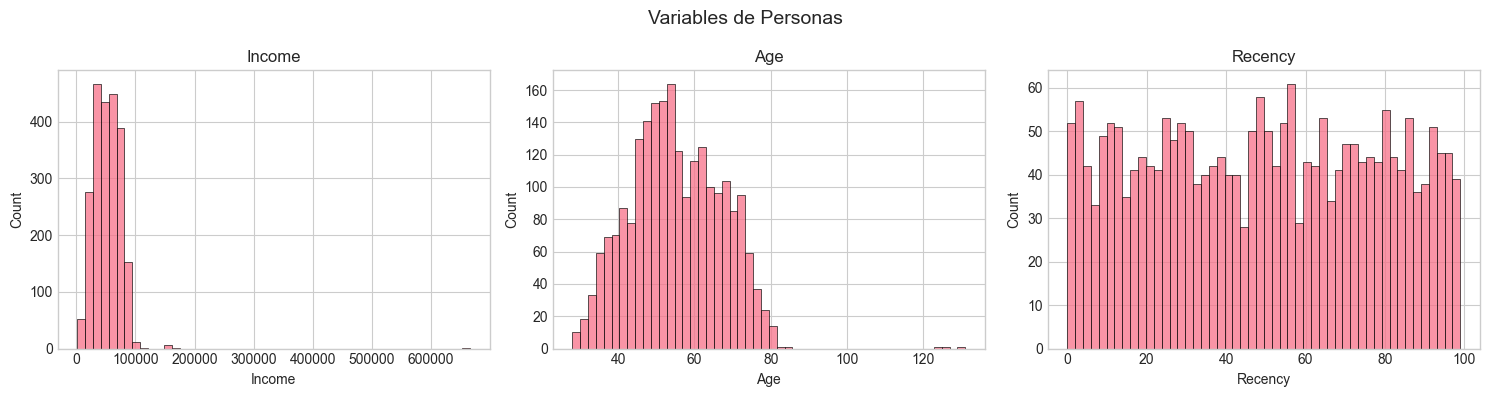

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Variables de Personas', fontsize=14)
for i, col in enumerate(personas_continuas):
    sns.histplot(data=dataset, x=col, ax=axes[i], bins=50)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

Se observa que:

**Income:** tiene una asimetría positiva con un pico aproximadamente en 50000. La mayoría de los clientes tienen un Income entre 40000 y 70000 aproximadamente. También se visualiza un oulier muy grande en el extremo de 670000 aproximadamente que se deberá analizar con mayor detalle.

**Age:** tiene una distribución muy parecida a la normal, es bastante simétrica. La mayoría de las personas está entre los 45 y 65 años aproximadamente con un pico cerca de los 50 años. Así también se visualizan valores atípicos e uno de los extremos con edades superiores a las 120 años lo cual no tiene sentido, y probablemente sean errores de entrada que hay que analizar que hacer con ellos. 

**Recency:** tiene una distribución uniforme con valores dispersos entre 0 y 99 días aproximadamente. Parece no seguir un patrón específico, no se observa concentración en algún tipo de rango, ni outliers evidentes, es decir no es visible una tendencia dominante en la recencia de los clientes. Lo que si se visualiza es que hay mayor variabilidad en días menores a los 60 luego la variabilidad parece disminuir un poco.

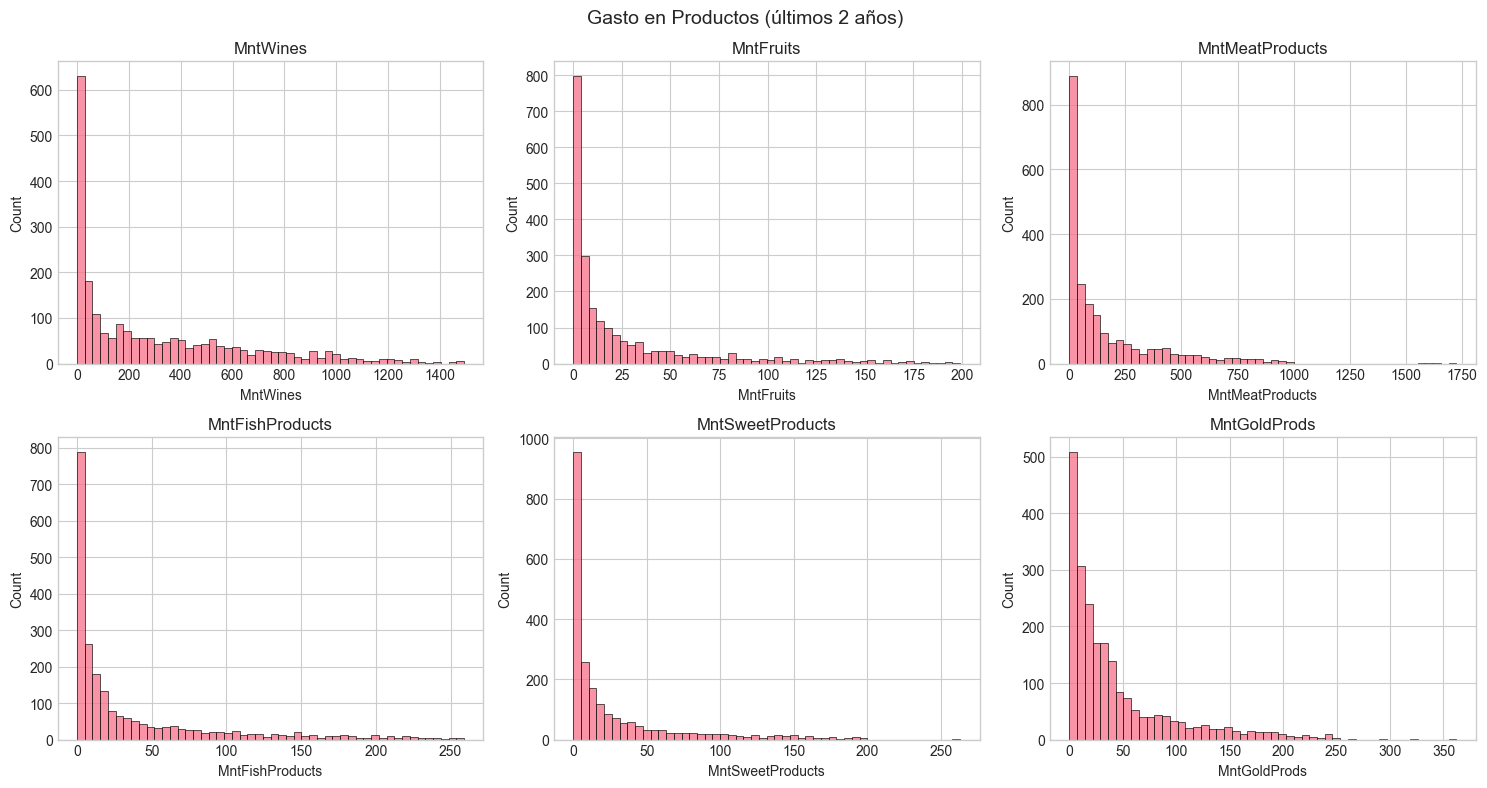

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Gasto en Productos (últimos 2 años)', fontsize=14)
for i, col in enumerate(productos):
    ax = axes[i // 3, i % 3]
    sns.histplot(data=dataset, x=col, ax=ax, bins=50)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Se observan las distribuciones **MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, MntGoldProds**, las cuales representan el importe gastado en vino en los últimos 2 años, el importe gastado en frutas en los últimos 2 años, importe gastado en productos cárnicos en los últimos 2 años, importe gastado en pescado en los últimos 2 años, el importe gastado en productos dulces en los últimos 2 años y el importe gastado en productos de oro en los últimos 2 años tienen una asimetría positiva con un pico en 0, donde se visualizan distribuciones que se asemejan a la exponencial.

Para cada producto hay un importe máximo gastado diferente por ejemplo para los vinos se gasta un poco mas que 1400, en frutas los clientes han gastado hasta 200 aproximadamente, en carnes han gastado casi hasta 1750 (entre 1500 y 1750 se visualiza un pequeño grupo que ha comprado más), en productos de percado se ha gastado hasta un poco mas que 250, en productos dulces se visualiza un máximo por encima de 250, como un outlier es decir que no es tan común y en productos de oro un máximo superior a 350 que tampoco es tan común. Estas distribuciones presentan algo de variabilidad pero siguen un patrón similar a la distribución exponencial en general.

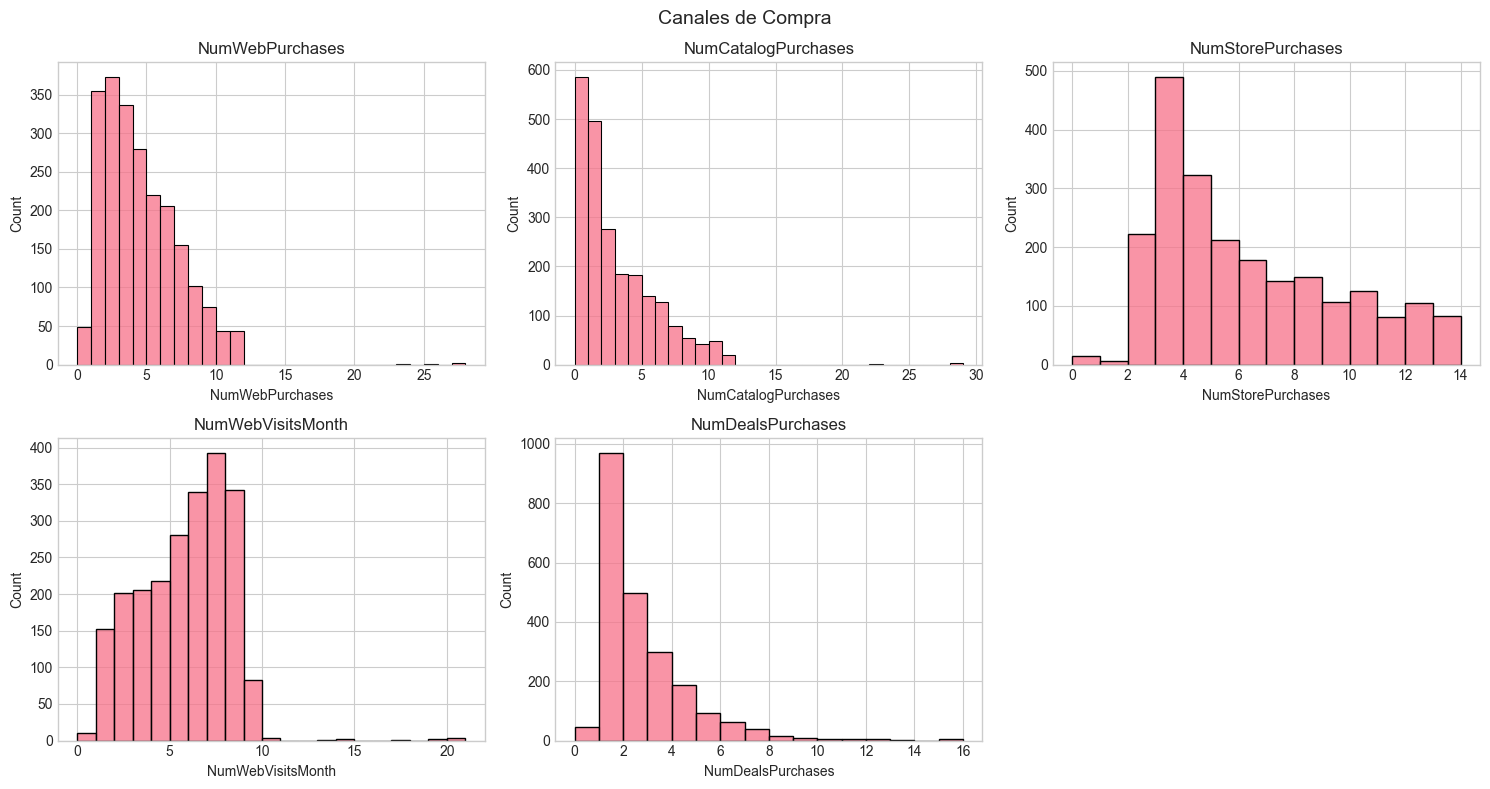

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Canales de Compra', fontsize=14)
for i, col in enumerate(canales):
    ax = axes[i // 3, i % 3]
    sns.histplot(data=dataset, x=col, ax=ax, bins=range(0, dataset[col].max()+2))
    ax.set_title(col)
axes[1, 2].axis('off') 
plt.tight_layout()
plt.show()

**NumWebPurchases:** tiene una asimetría positiva con una concentración de clientes entre 1 y 6 compras en la web. Y se visualiza algunos valores atípicos alrededor de 25.

**NumCatalogPurchases:** tiene una asimetría positiva, sigue una distribución similar a la exponencial y se visualiza que la mayoría de los clientes realizan entre 0 y 3 compras por catálogo aproximadamente.

**NumStorePurchases:** tiene una distribución más variables con un pico en 3 compras.

**NumWebVisitsMonth:** el número de visitas web tiene un pico de 7 veces por mes, con una mayor concentración entre 5 y 8. También se visualiza que algunos clientes compran hasta 20 veces al mes.

**NumDealsPurchases:** tiene una asimetría positiva con un pico en 1 como el número de ofertas que se compran. Tiene una distribución parecida a la exponencial por lo que son muy pocos los clientes que aprovechan la mayoría de las ofertas.

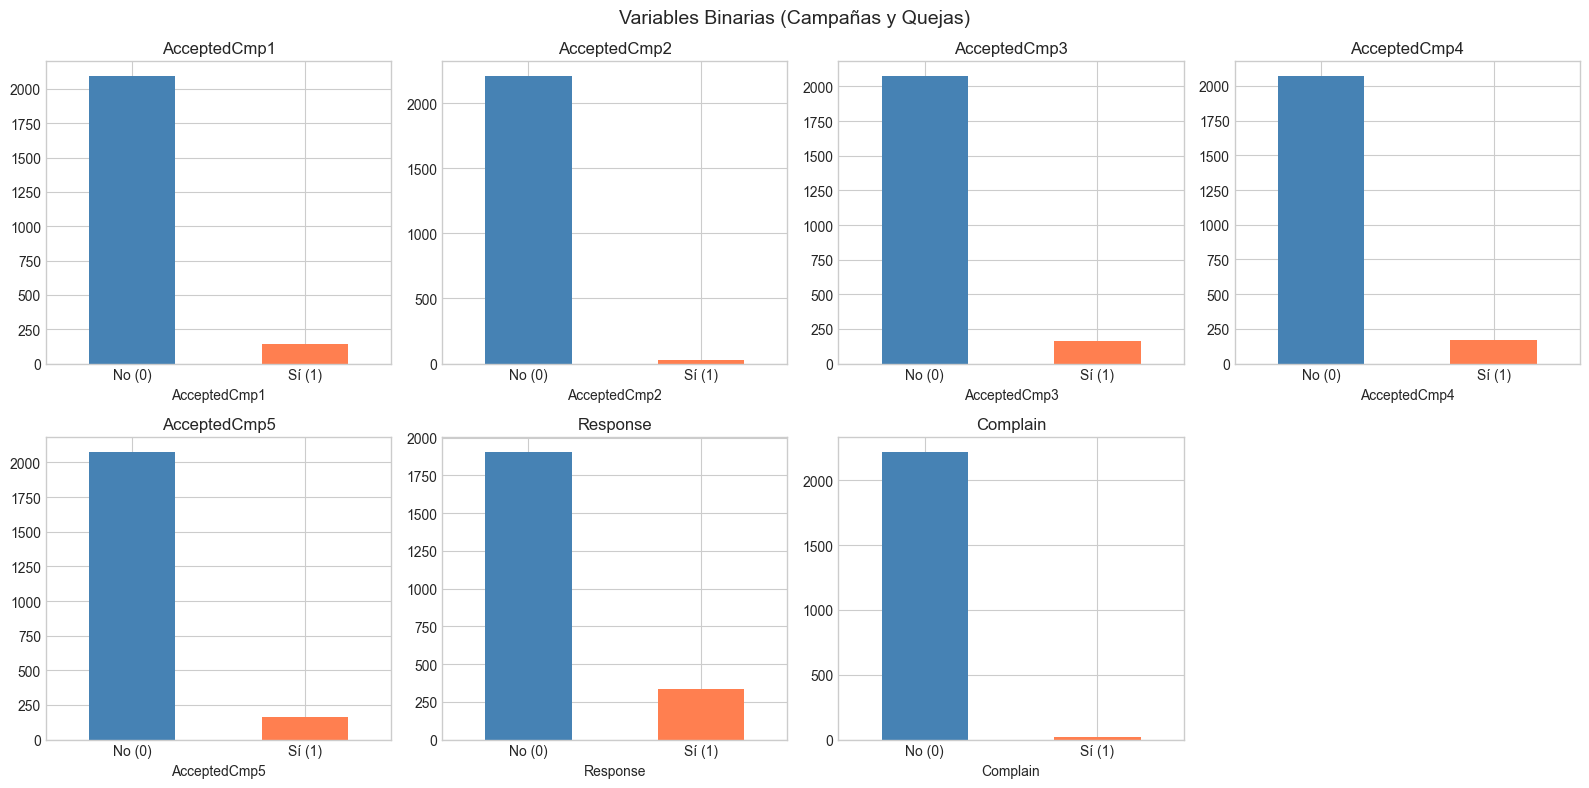

In [35]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Variables Binarias (Campañas y Quejas)', fontsize=14)
for i, col in enumerate(binarias):
    ax = axes[i // 4, i % 4]
    dataset[col].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
    ax.set_title(col)
    ax.set_xticklabels(['No (0)', 'Sí (1)'], rotation=0)
axes[1, 3].axis('off')
plt.tight_layout()
plt.show()

**AcceptedCmp1 a AcceptedCmp5:** de las campañas 1 al 5 la tasa de aceptación de los clientes es muy baja y menor que el 25% de las ofertas. La campaña 2 tiene la menor tasa de aceptación seguida por la 1. En general la mayoría de los clientes no aceptan las ofertas de las campañas.

**Response:** tiene la tasa de aceptación más alta que significa si el cliente aceptó la oferta en la última campaña, pero aún así es muy baja.

**Complain:** el indicador de quejas en los últimos 2 años, en el cualse visualiza muy pocas quejas, lo cual puede ser positivo para la empresa.

##### **1.1.2 Boxplots**

Para entender mejor la distribución hacemos gráficos de boxplots divididos por datos de personas, productos y canales de compras.

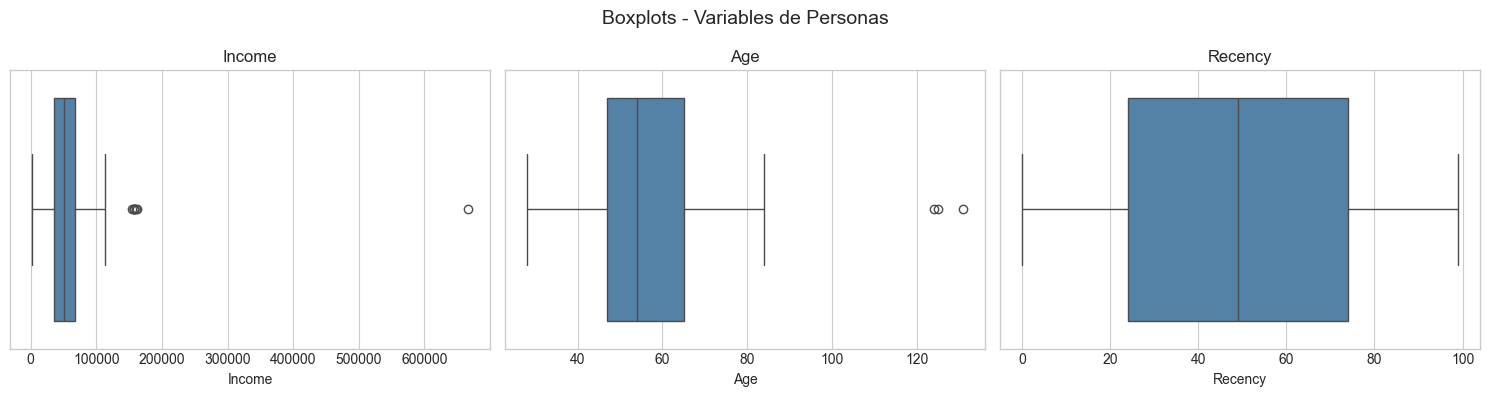

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Boxplots - Variables de Personas', fontsize=14)
for i, col in enumerate(personas_continuas):
    sns.boxplot(data=dataset, x=col, ax=axes[i], color='steelblue')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

Se observa que:

**Income:** el iqr está entre 35k y 70k aproximadamente, con una mediana cerca de 50k. Se visualizan outliers hacia la derecha por encima de 600k.

**Age:** el iqr está entre 47 y 65 años aproximadamente, con mediana en 54 aproximadamente. Se visualizan algunos outliers hacia la derecha con edades por encima de 120 años, lo cual no puede ser cierto.

**Recency:** tiene una distribución bastante simétrica, el iqr va de 25 a 75 aproximadamente con mediana en 50 aproximadamente y no se visualizan outliers.

A continuación graficamos las distribuciones relacionadas a los gastos de productos.

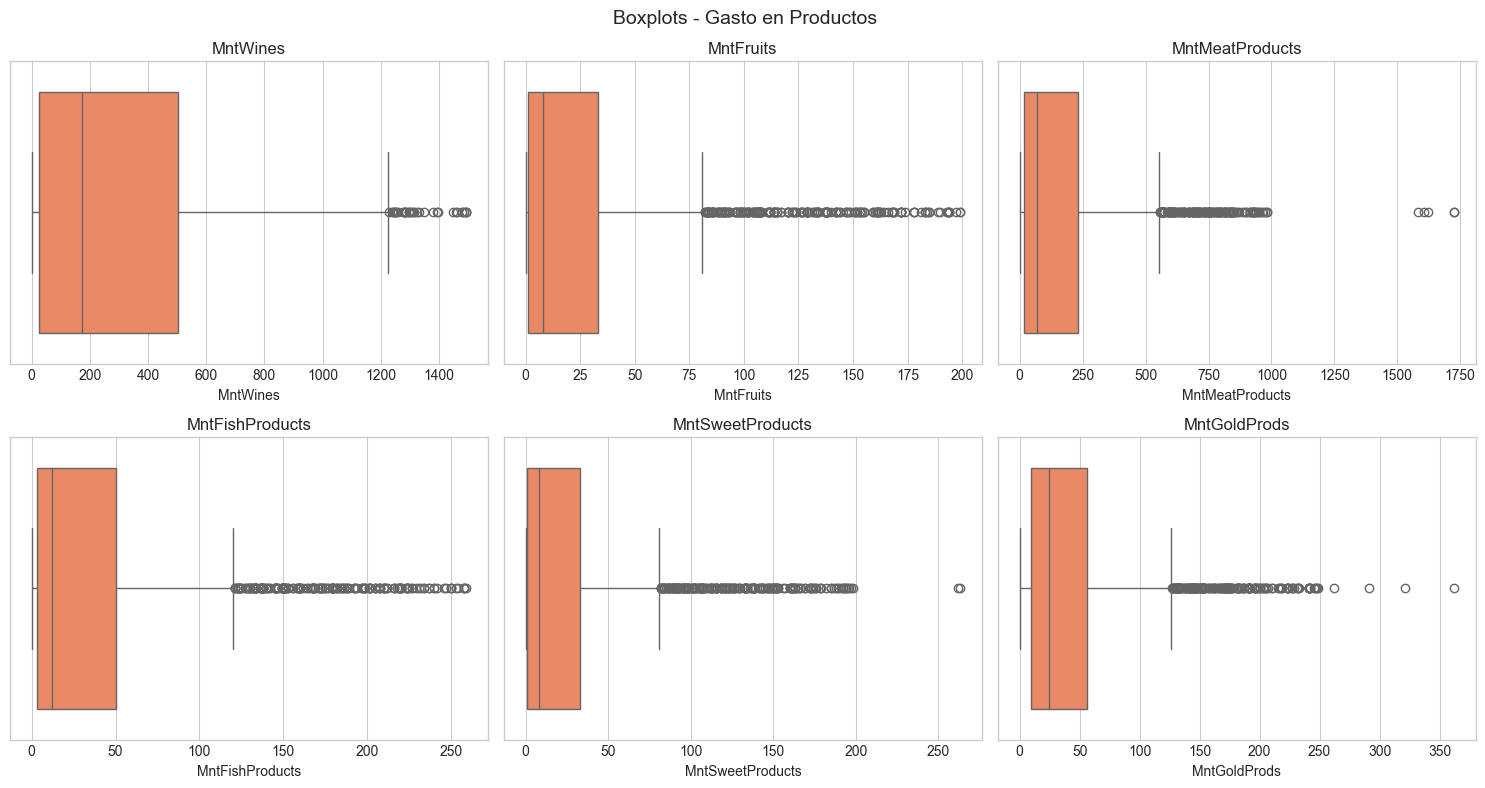

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Boxplots - Gasto en Productos', fontsize=14)
for i, col in enumerate(productos):
    ax = axes[i // 3, i % 3]
    sns.boxplot(data=dataset, x=col, ax=ax, color='coral')
    ax.set_title(col)
plt.tight_layout()
plt.show()

Donde se observa que:

**MntWines:** el iqr está entre 20 y 500 aproximadamente con mediana en 180 aproximadamente, se visualiza una asimetría positiva, outliers altos y una cola a la derecha.

**MntFruits:** tiene una asimetría positiva con cola a la derecha, el iqr está entre 1 y 30 aproximadamente con mediana en 10 aproximadamente, se visualizan muchos outliers hacia la derecha que van desde 78 a 200 aproximadamente.

**MntMeatProducts:** el iqr parece estar entre 15 y 240 aproximadamente con mediana en 70 aproximadamente, se visualizan muchos outliers que van por encima de 500 hasta 1000 y luego otro grupo por encima de 1500 hasta 1750 aproximadamente.

**MntFishProducts:** el iqr está entre 3 y 50 aproximadamente con mediana en 10 aproximadamente, tiene una asimetría positiva y cola a la derecha. También se visualizan muchos outliers por encima de 120 aproximadamente.

**MntSweetProducts:** el iqr está entre 1 y 35 aproximadamente con mediana cerca de 10, tiene una asimetría positiva y cola a la derecha. También se visualizan outliers por encima de 85 aproximadamente.

**MntGoldProds:** el iqr está entre 10 y 50 aproximadamente con mediana en 20, tiene una asimetría positiva y cola a la derecha con muchos ouliers.

Luego graficamos las distribuciones relacionadas a los canales de compras.

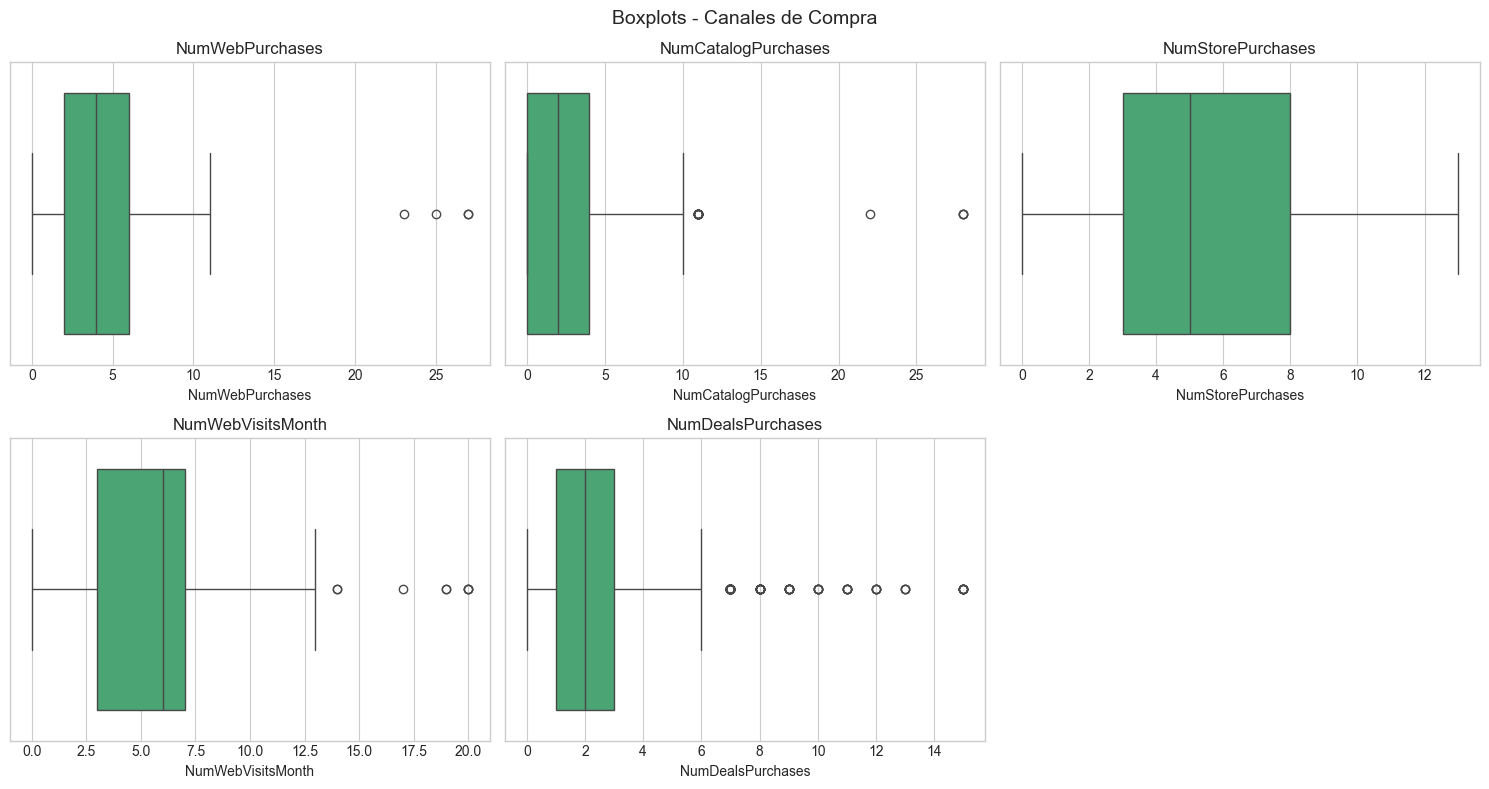

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Boxplots - Canales de Compra', fontsize=14)
for i, col in enumerate(canales):
    ax = axes[i // 3, i % 3]
    sns.boxplot(data=dataset, x=col, ax=ax, color='mediumseagreen')
    ax.set_title(col)
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

Luego en los canales de compra:

**NumWebPurchases:** el iqr está entre 2 y 6 aproximadamente con mediana en 4. Tiene una asimetría positiva y cola a la derecha, con pocos outliers pero altos.

**NumCatalogPurchases:** el iqr está entre 0 y 4 aproximadamente con mediana en 2. Tiene asimetría positiva y cola a la derecha con outliers altos.

**NumStorePurchases:** el iqr está entre 3 y 8 aproximadamente con mediana en 5. Tiene una distribución más simétrica, colas cortas y sin outliers.

**NumWebVisitsMonth:** el iqr está entre 3 y 7 aproximadamente con mediana en 6. Tiene asimetría positiva y cola a la derecha con algunos outliers.

**NumDealsPurchases:** el iqr está entre 1 y 3 aproximadamente con mediana en 2. Tiene asimetría positiva marcada y cola a la derecha con varios outliers que van desde 7 hasta 15.

##### **1.1.3 Histogramas y boxplots juntos**

Para visualizar las variables numéricas con histogramas y boxplots juntos armamos las siguientes visualizaciones donde se pueden ver la forma de la distribución, junto con la mediana, la media (lo cual ayuda para distinguir si la distribución esta sesgada), el iqr, las colas y los outliers. A continuación se visualizan para los datos relacionados a las personas.

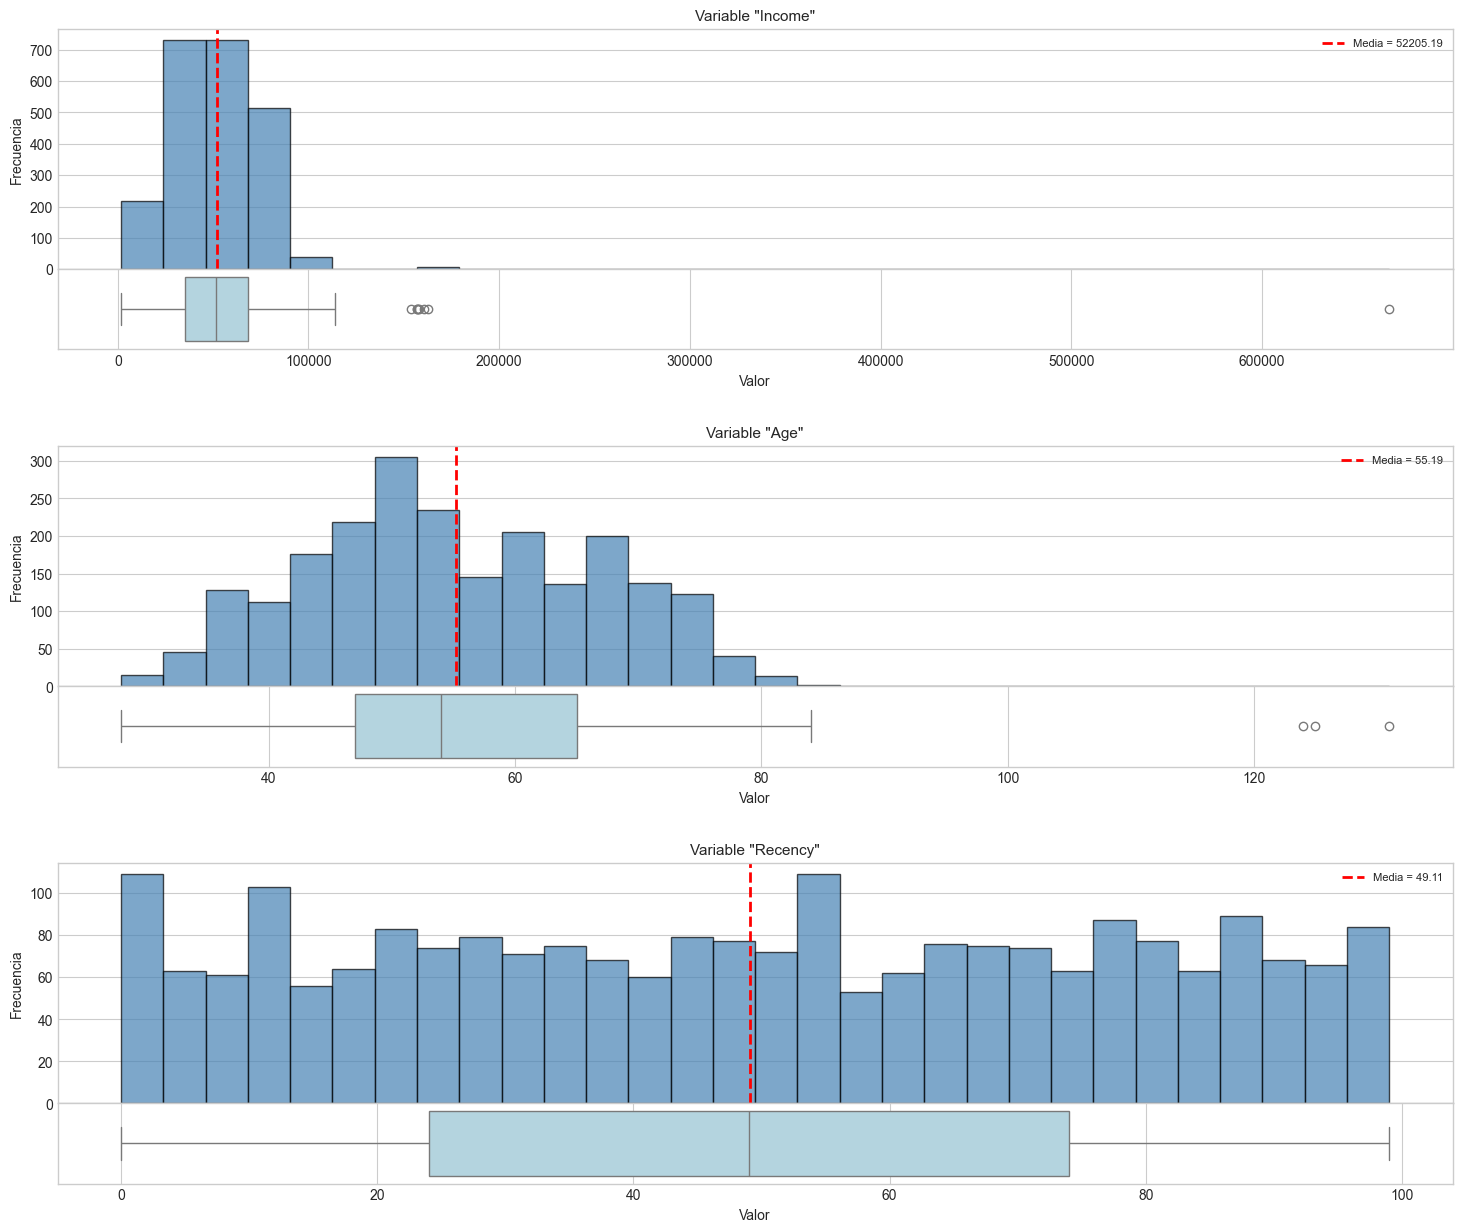

In [39]:
fig = plt.figure(figsize=(18, 5 * len(personas_continuas)))
outer = gridspec.GridSpec(len(personas_continuas), 1, wspace=0.2, hspace=0.3)
for i, col in enumerate(personas_continuas):
    inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[i], height_ratios=[3, 1], hspace=0)
    data = dataset[col].dropna()
    mean_val = data.mean()
    #Histograma
    ax_hist = plt.Subplot(fig, inner[0])
    ax_hist.hist(data, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax_hist.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f"Media = {mean_val:.2f}")
    ax_hist.set_title(f'Variable "{col}"', fontsize=11)
    ax_hist.set_ylabel("Frecuencia")
    ax_hist.set_xticks([])
    ax_hist.legend(loc='upper right', fontsize=8)
    fig.add_subplot(ax_hist)
    #Boxplot
    ax_box = plt.Subplot(fig, inner[1])
    sns.boxplot(x=data, ax=ax_box, orient="h", color="lightblue")
    ax_box.set_xlabel("Valor")
    fig.add_subplot(ax_box)
plt.tight_layout()
plt.show()

En las variables de personas se observa que **Income** tiene una asimetría positiva con una cola a la derecha. La mayoría de los clientes se concentra cerca de la media a excepcion de algunos clientes con valores muy altos que hacen que la media se desplace más a la derecha, que en el boxplot se ven como outliers. 
**Age** tiene una distribución parecida a la normal con mayor concentración en edades medias, aunque también se visualiza valores atípicos en edades muy altas, lo que genera una cola a la derecha, que podría incluso significar que hay más de un grupo en esa variable. **Recency** tiene valores repartidos a lo largo del rango con colas similares y sin outliers vivibles en el boxplot.


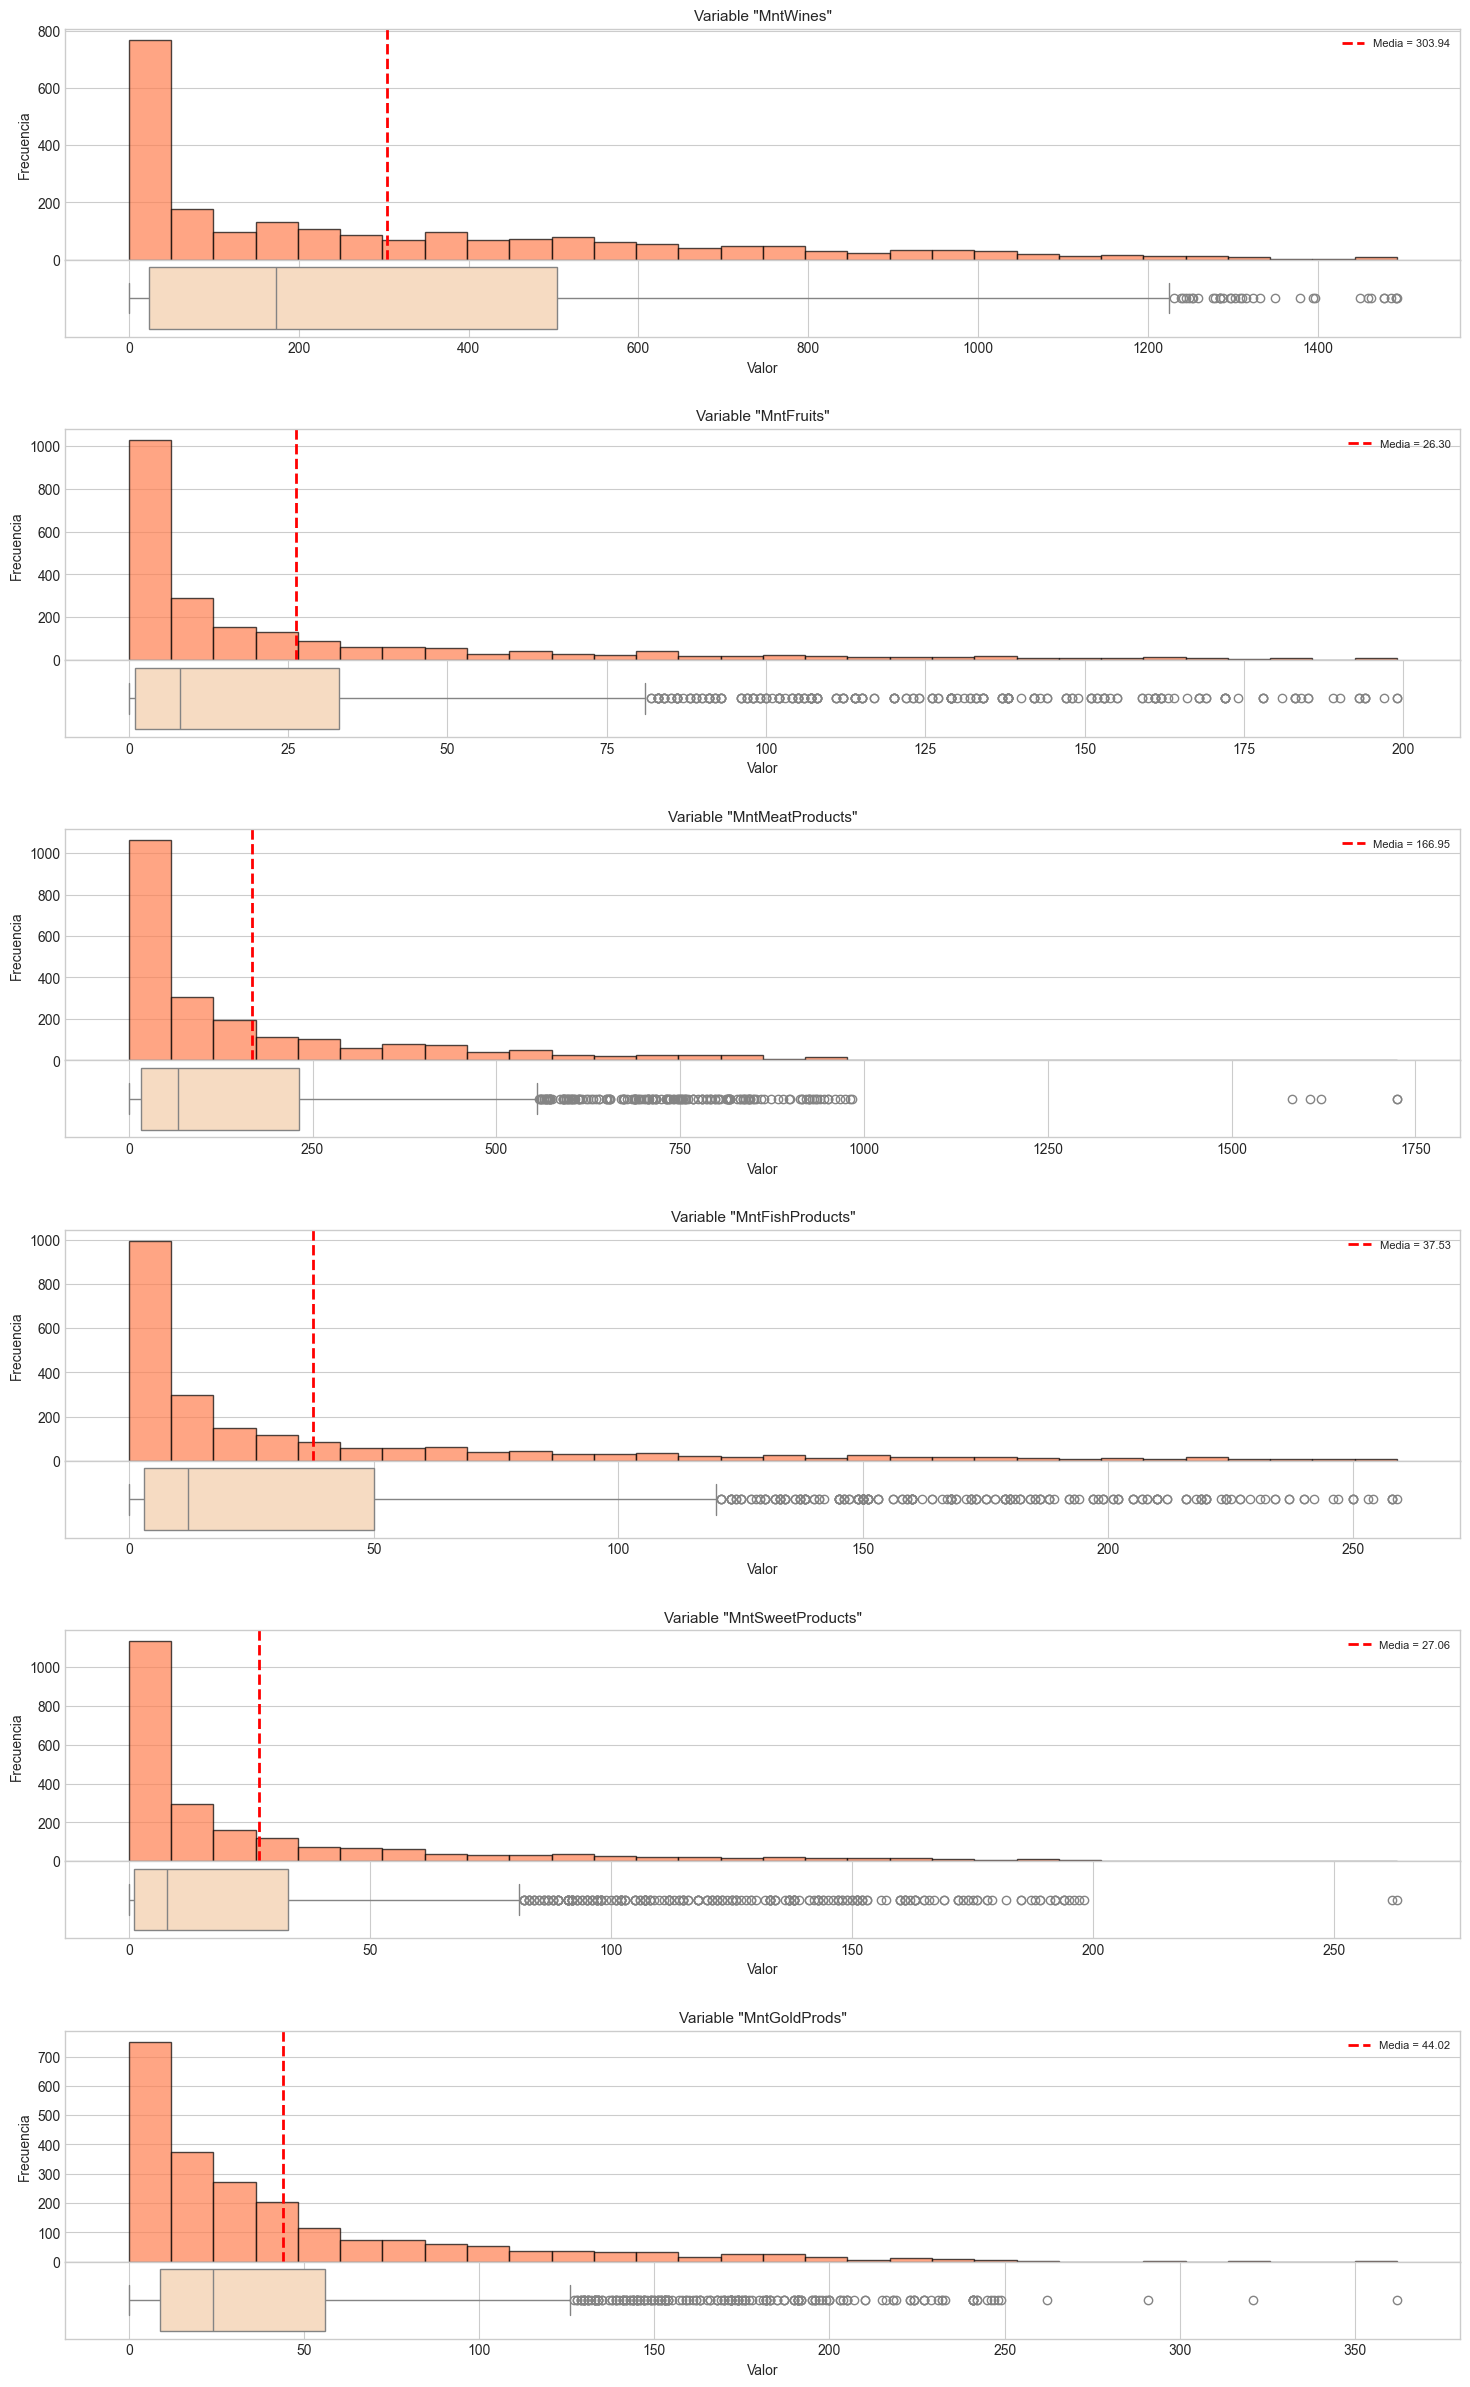

In [40]:
fig = plt.figure(figsize=(18, 5 * len(productos)))
outer = gridspec.GridSpec(len(productos), 1, wspace=0.2, hspace=0.3)
for i, col in enumerate(productos):
    inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[i], height_ratios=[3, 1], hspace=0)
    data = dataset[col].dropna()
    mean_val = data.mean()
    ax_hist = plt.Subplot(fig, inner[0])
    ax_hist.hist(data, bins=30, color='coral', edgecolor='black', alpha=0.7)
    ax_hist.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f"Media = {mean_val:.2f}")
    ax_hist.set_title(f'Variable "{col}"', fontsize=11)
    ax_hist.set_ylabel("Frecuencia")
    ax_hist.set_xticks([])
    ax_hist.legend(loc='upper right', fontsize=8)
    fig.add_subplot(ax_hist)
    ax_box = plt.Subplot(fig, inner[1])
    sns.boxplot(x=data, ax=ax_box, orient="h", color="peachpuff")
    ax_box.set_xlabel("Valor")
    fig.add_subplot(ax_box)
plt.tight_layout()
plt.show()

En los gastos de productos **MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts y MntGoldProds** se visualiza un patrón con asimetría positiva y un pico grande en 0, lo que quiere decir que muchos clientes gastan poco o nada, con una cola larga a la derecha, que significa que pocos clientes son los que gastan mucho. 

En todos los boxplots se visualiza a la mediana más cercana al Q1, es decir que se concentran en valores más bajos y muchos outliers a la derecha el cual es más notorio en **MntWines** y **MntMeatProducts** porque poseen un gasto más elevado.


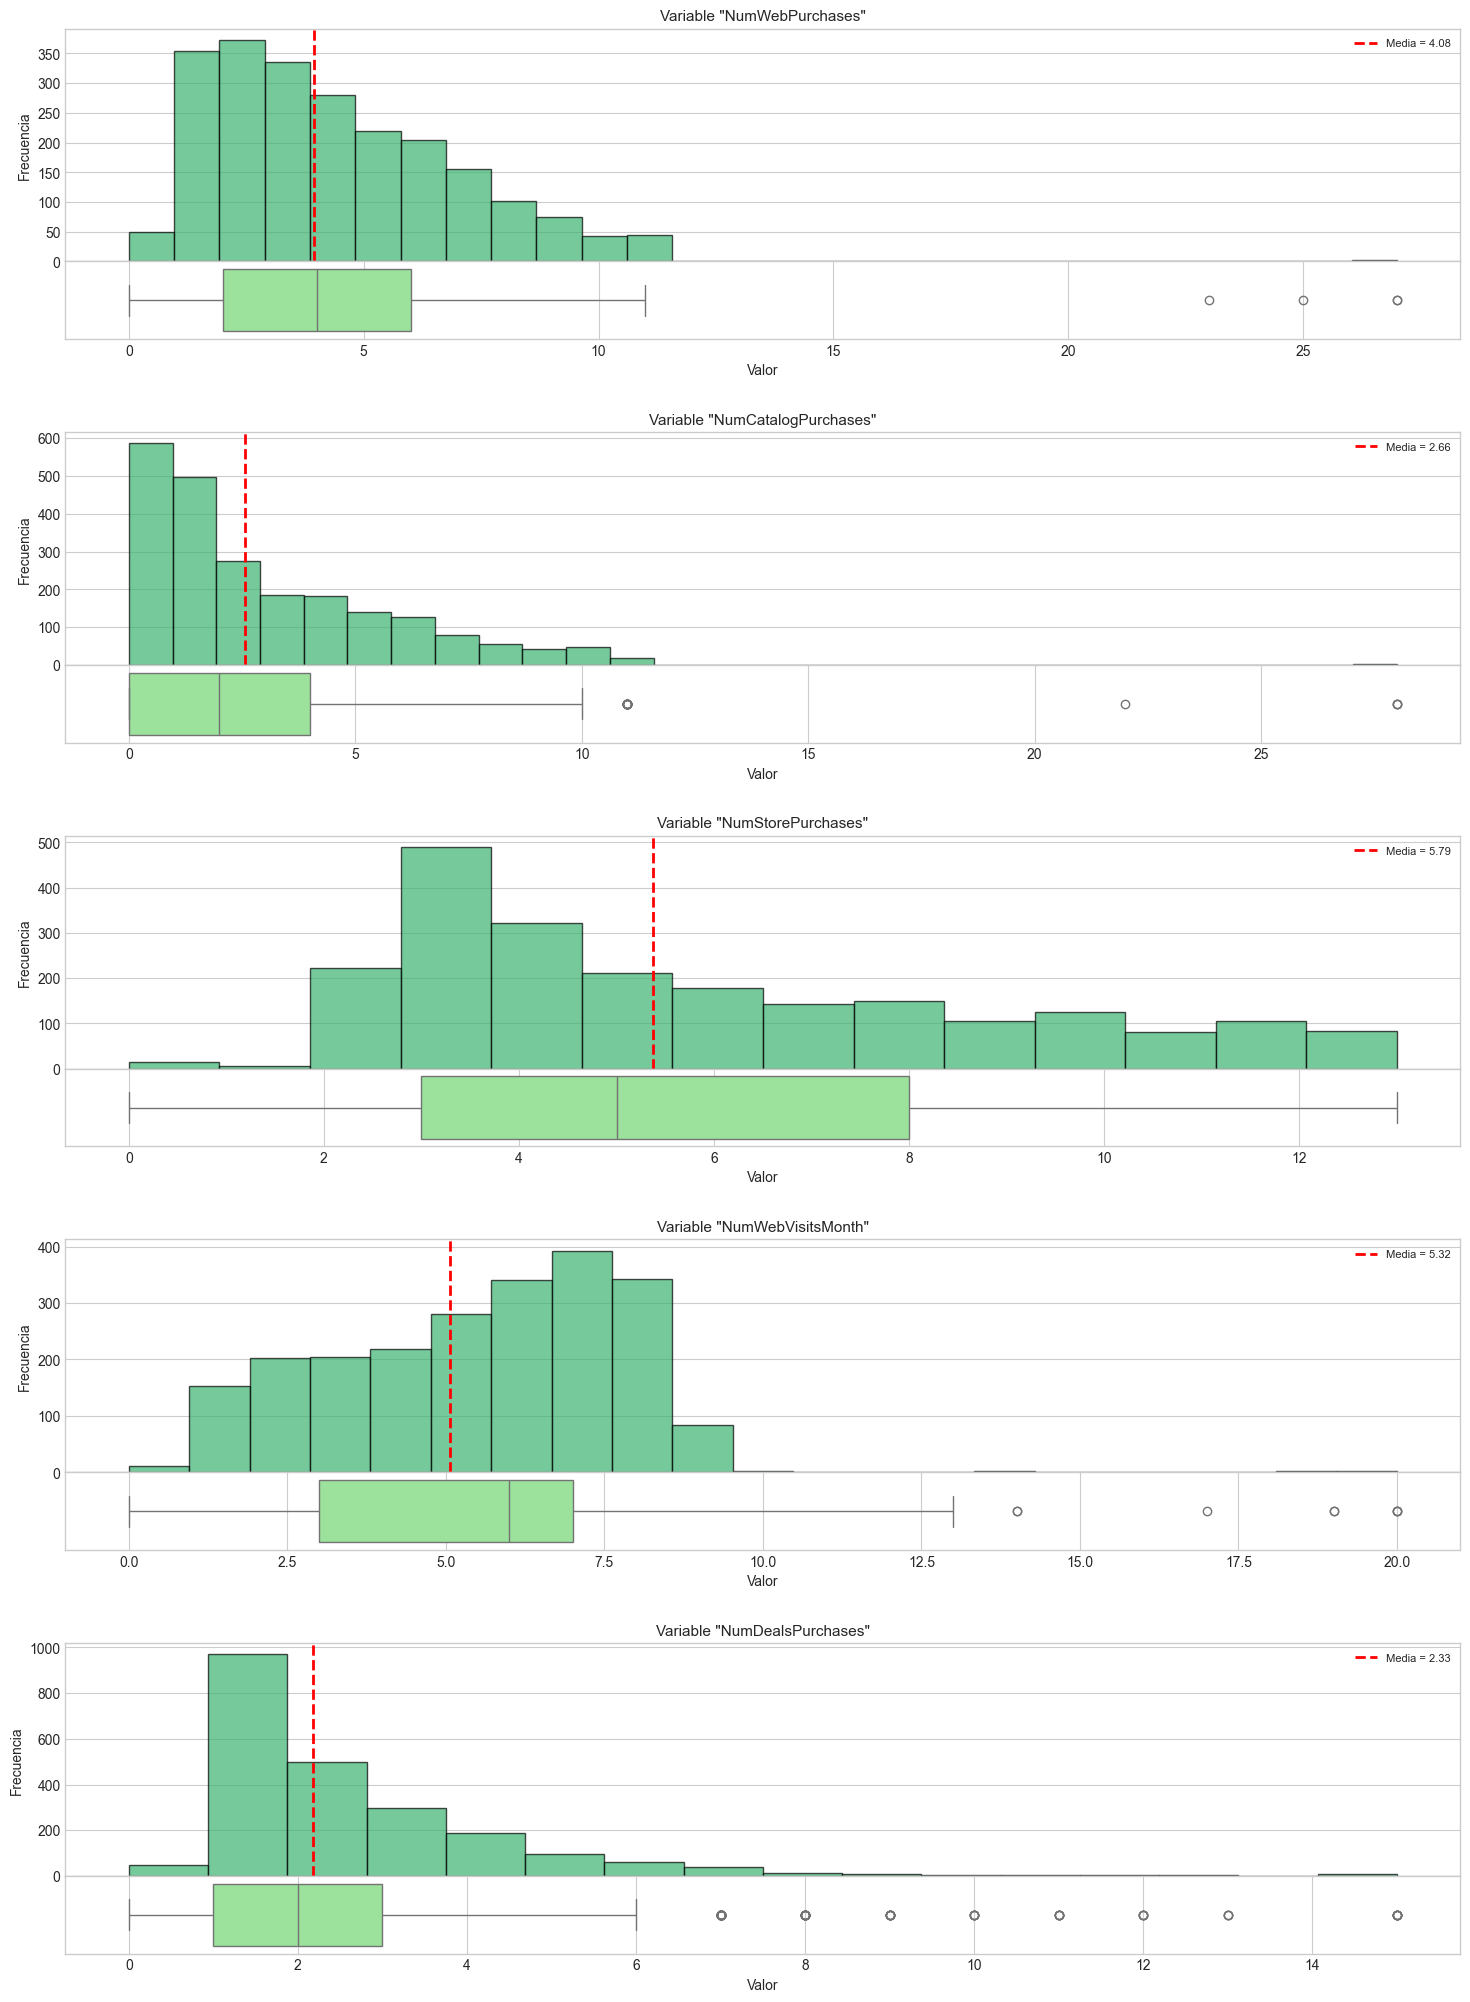

In [41]:
fig = plt.figure(figsize=(18, 5 * len(canales)))
outer = gridspec.GridSpec(len(canales), 1, wspace=0.2, hspace=0.3)
for i, col in enumerate(canales):
    inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[i], height_ratios=[3, 1], hspace=0)
    data = dataset[col].dropna()
    mean_val = data.mean()
    ax_hist = plt.Subplot(fig, inner[0])
    ax_hist.hist(data, bins=range(0, int(data.max())+2), color='mediumseagreen', edgecolor='black', alpha=0.7)
    ax_hist.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f"Media = {mean_val:.2f}")
    ax_hist.set_title(f'Variable "{col}"', fontsize=11)
    ax_hist.set_ylabel("Frecuencia")
    ax_hist.set_xticks([])
    ax_hist.legend(loc='upper right', fontsize=8)
    fig.add_subplot(ax_hist)
    ax_box = plt.Subplot(fig, inner[1])
    sns.boxplot(x=data, ax=ax_box, orient="h", color="lightgreen")
    ax_box.set_xlabel("Valor")
    fig.add_subplot(ax_box)
plt.tight_layout()
plt.show()

Y finalmente en los canales de compra se observa que **NumWebPurchases** y **NumCatalogPurchases** tienen asimetría positiva, donde la mayoría de los clientes realiza pocas compras y aparece una cola a la derecha con algunos valores más altos. Luego **NumStorePurchases** tiene una asimetría a la derecha con mayot concentración en 3 y 4 con una media en 5, y muy pocos valores en 0 y 1 lo que significa que la mayoría que compra en la tienda, suele comprar mas de dos productos.

**NumWebVisitsMonth** el número de visitas que se hacen en la web tiene un pico en 7 aproximadamente, con una media alrededor de 5 y mediana alrededor de 6, posiblemente haya como un grupo que visite menos y otro que más, se podría analizar más a profundidad, así también tiene algunos outliers que representan clientes que llegan a visitar hasta 20 veces al mes la web. **NumDealsPurchases** tiene asimetría positiva con un pico en 1, es decir que la mayoría de los clientes suele aprovechar una oferta nomas, y son muy pocos los que aprovechan la mayoría de las ofertas.

##### **1.1.4 Test de Normalidad Shapiro-Wilk**

Para el análisis de la normalidad utilizamos el test de Shapiro-Wilk que verifica si una muestra proviene de una distribución normal. Donde hacemos dos hipótesis:

- H₀ (Hipótesis nula): Los datos siguen una distribución normal
- H₁ (Hipótesis alternativa): Los datos NO siguen una distribución normal

Si el test de Shapiro-Wilk es cercano a 1, la distribución es más compatible con la normalidad y si es cercano a cero es menos.

Si:
- p > 0.05: No se rechaza la hipótesis nula, ya que no podemos asumir normalidad.
- p ≤ 0.05: Se rechaza la hipótesis nula.

In [42]:
cols_shapiro = ['Income','Age','Recency','MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds','NumWebPurchases','NumCatalogPurchases','NumStorePurchases',
'NumWebVisitsMonth','NumDealsPurchases']
for col in cols_shapiro:
    data = dataset[col].dropna()
    stat, p_value = stats.shapiro(data)
    print(f"{col}: estadístico={stat:.4f}, p-valor={p_value:.4f}")

Income: estadístico=0.7776, p-valor=0.0000
Age: estadístico=0.9757, p-valor=0.0000
Recency: estadístico=0.9541, p-valor=0.0000
MntWines: estadístico=0.8381, p-valor=0.0000
MntFruits: estadístico=0.6891, p-valor=0.0000
MntMeatProducts: estadístico=0.7298, p-valor=0.0000
MntFishProducts: estadístico=0.7086, p-valor=0.0000
MntSweetProducts: estadístico=0.6867, p-valor=0.0000
MntGoldProds: estadístico=0.7671, p-valor=0.0000
NumWebPurchases: estadístico=0.8979, p-valor=0.0000
NumCatalogPurchases: estadístico=0.8149, p-valor=0.0000
NumStorePurchases: estadístico=0.9045, p-valor=0.0000
NumWebVisitsMonth: estadístico=0.9299, p-valor=0.0000
NumDealsPurchases: estadístico=0.7398, p-valor=0.0000


Para todas las variables el p-valor del test de Shapiro-Wilk es 0.05<, por lo tanto no se cumple el supuesto de normalidad, entonces rechazamos la hipótesis nula. Lo cual coincide con lo que hemos visualizado en los histogramas y boxplots. Para hacer el clustering no es un requisito que las distribuciones sean normales, pero es fundamental hacer este test para tratar los outliers vistos de manera adecuada.



### 1.2 Variables categóricas

Separamos las variables categóricas del dataset.

In [43]:
dataset_categorical = dataset.select_dtypes(exclude=[np.number])
print(f"Variables categóricas: {list(dataset_categorical.columns)}")

Variables categóricas: ['Education', 'Marital_Status', 'Dt_Customer', 'Age_Group']


#### **1.2.1 Gráfico de cantidades**

Mediante graficos de barras graficamos la cantidad de clientes por nivel educativo y por el estado civil.

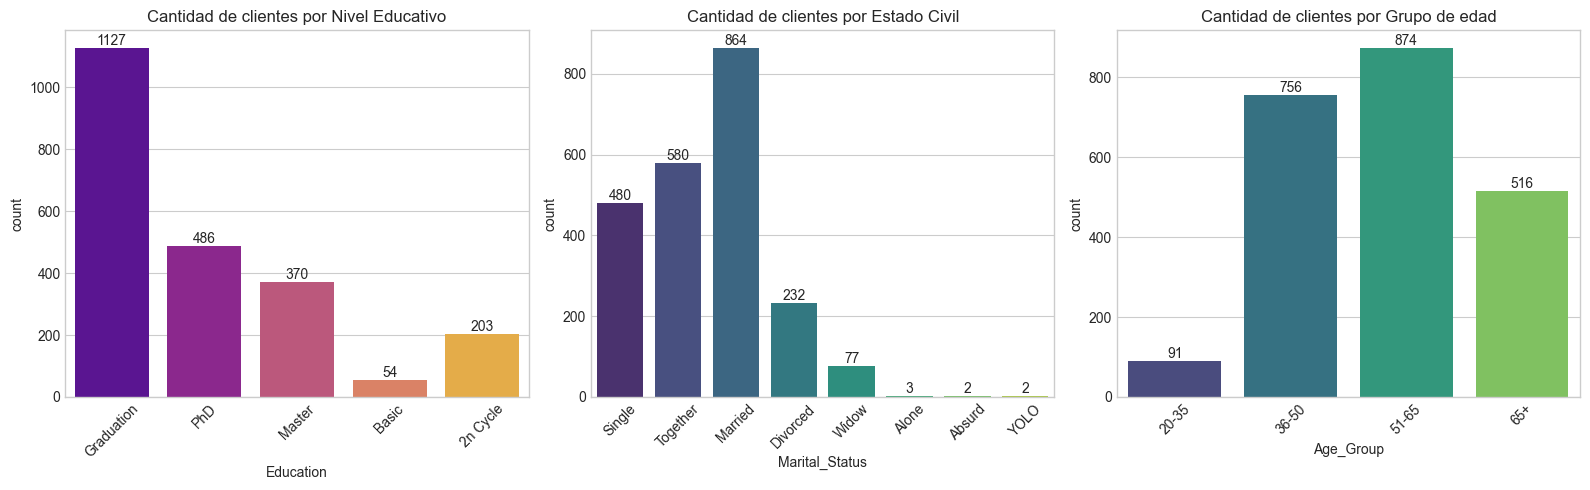

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax1 = sns.countplot(data=dataset, x="Education", ax=axes[0], palette="plasma")#Educación
for cont in ax1.containers:
    ax1.bar_label(cont)
ax1.set_title("Cantidad de clientes por Nivel Educativo")
axes[0].tick_params(axis='x', rotation=45)

ax2 = sns.countplot(data=dataset, x="Marital_Status", ax=axes[1], palette="viridis")#Estado civil
for cont in ax2.containers:
    ax2.bar_label(cont)
ax2.set_title("Cantidad de clientes por Estado Civil")
axes[1].tick_params(axis='x', rotation=45)

ax3 = sns.countplot(data=dataset, x="Age_Group", ax=axes[2], palette="viridis")#Grupo de edad
for cont in ax3.containers:
    ax3.bar_label(cont)
ax3.set_title("Cantidad de clientes por Grupo de edad")
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Cantidad de clientes por nivel educativo:** se visualiza que la mayor parte de clientes son graduados, seguidos por PhD, Masters, ciclo Básico y por último y minoría los de 2n Cycle.

**Cantidad de clientes por estado civil:** la mayor parte de los clientes son personas casadas, seguidas por los Together, los singles, los divorciados, Widow y en mucha menor medida en comparación a la muestra: Alone, Absurd y YOLO.

**Cantidad de clientes por grupo de edad:** se observa que la mayoría de los clientes pertenecen al grupo de 51-65 años con 874 clientes, seguido por el grupo de 36-50 años con 756 clientes. El grupo de 20-35 años tiene la menor cantidad con 91 y el grupo mayores de 65 años tiene 516 clientes.

#### **1.2.2 Gráfico de barras de income por categoría**

Se visualizan los ingresos promedio por nivel educativo y por estado civil mediante gráficos de barras.

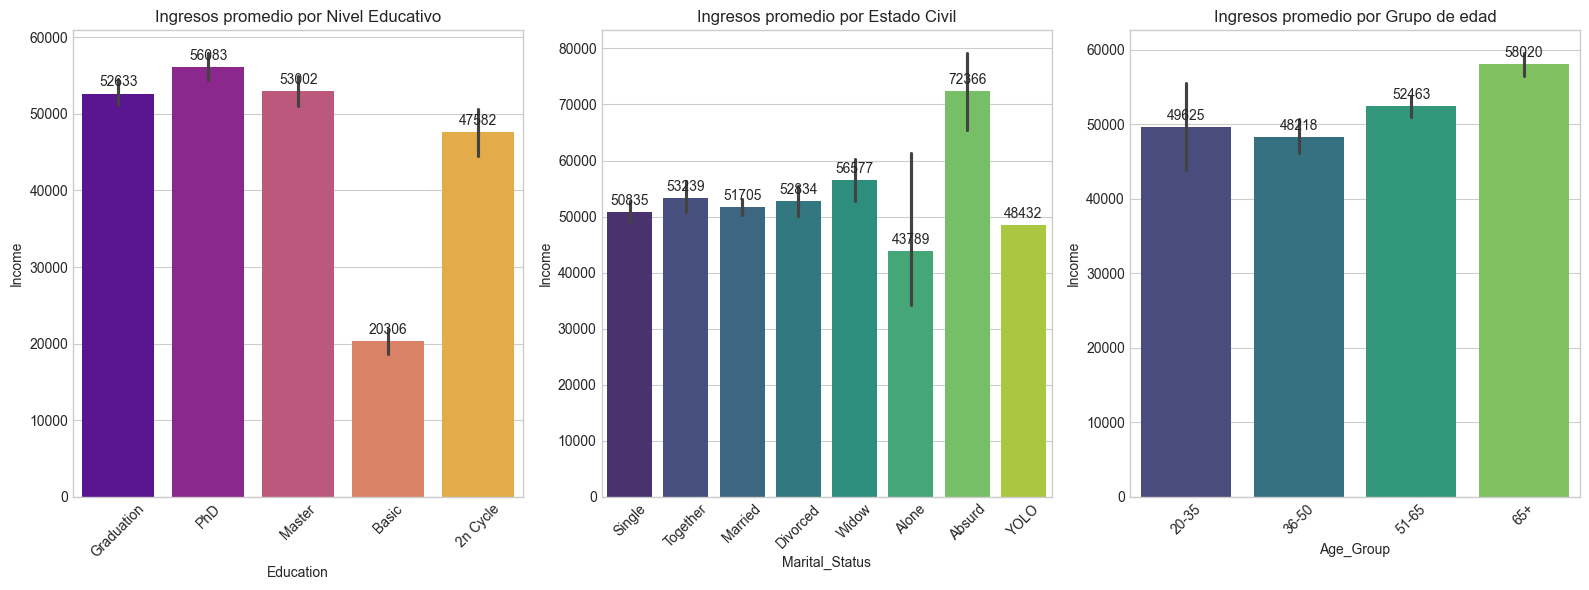

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
sns.barplot(data=dataset, x="Education", y="Income", ax=axes[0], palette="plasma")#Income por Education
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.0f', padding=3)
axes[0].set_title("Ingresos promedio por Nivel Educativo")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=dataset, x="Marital_Status", y="Income", ax=axes[1], palette="viridis")#Income por Marital_Status
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.0f', padding=3)
axes[1].set_title("Ingresos promedio por Estado Civil")
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(data=dataset, x="Age_Group", y="Income", ax=axes[2], palette="viridis")#Income por Age_Group
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.0f', padding=3)
axes[2].set_title("Ingresos promedio por Grupo de edad")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Ingresos promedio por nivel educativo:** los clientes con PhD tienen el ingreso promedio más alto con 56083, seguido por Masters con 53002 y Graduation con 52633 que tienen valores similares entre sí. Luego los clientes de 2n Cycle que tienen un ingreso promedio de 47582 y clientes con educación basica tienen el Income más bajo del grupo con 20306.

**Ingresos promedio por estado civil:** se observa que la categoría Absurd tiene el income promedio más alto del grupo con 72366, aunque esta categoría tiene muy pocos datos. Luego clientes Widow tienen el segundo ingreso promedio más alto con 56577, seguido por Together con 53339, Divorced con 52834, Married con 51705 y Single con 50835. A los cuales le siguen los grupos YOLO con un income de 48432 y Alone con 43789 el cual es el más bajo de todo el grupo.

**Ingresos promedio por grupo de edad:** la diferencia entre los ingresos por grupo no es muy grande, donde el grupo con mayores ingresos el de los mayores de 65 años con 58020, y el que menos ingresos tiene es el de 36-50 con 48128.

#### **1.2.3 Gráfico de violín**

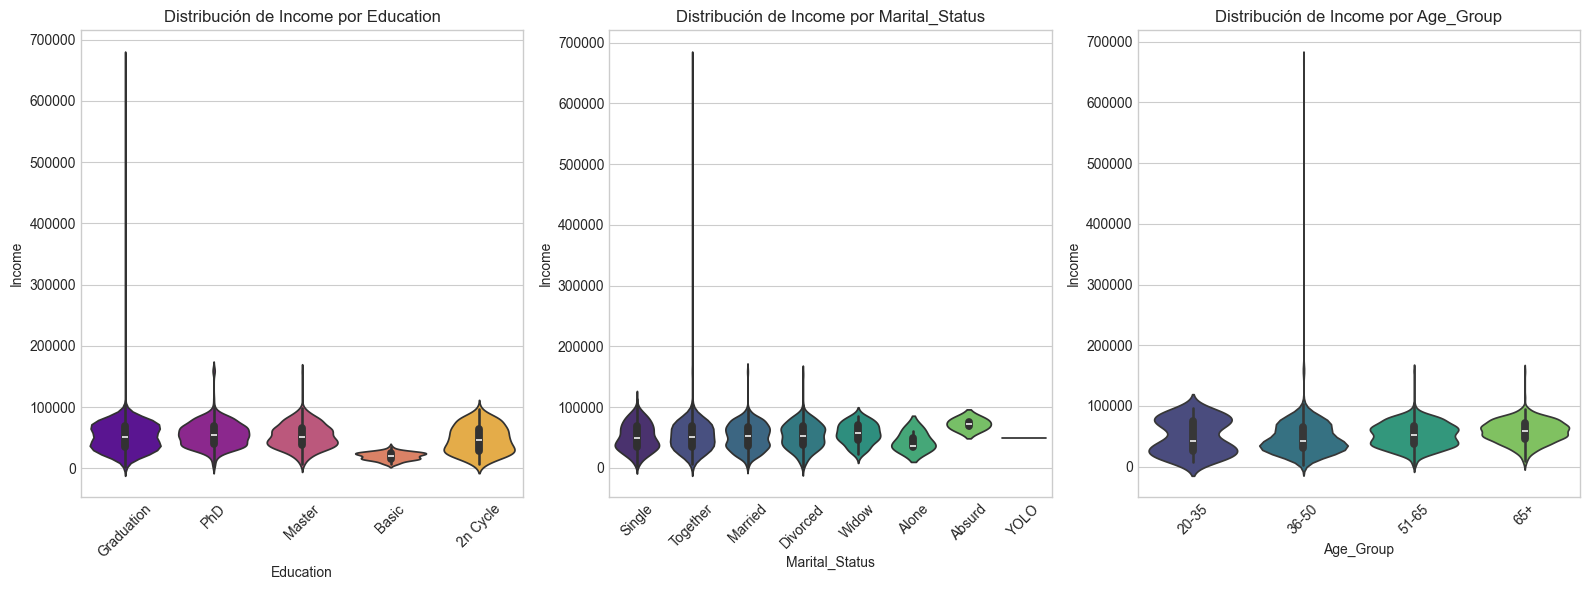

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
sns.violinplot(data=dataset, x="Education", y="Income", ax=axes[0], palette="plasma")#Income vs Education
axes[0].set_title("Distribución de Income por Education")
axes[0].tick_params(axis='x', rotation=45)

sns.violinplot(data=dataset, x="Marital_Status", y="Income", ax=axes[1], palette="viridis")#Income vs Marital_Status
axes[1].set_title("Distribución de Income por Marital_Status")
axes[1].tick_params(axis='x', rotation=45)

sns.violinplot(data=dataset, x="Age_Group", y="Income", ax=axes[2], palette="viridis")#Income vs Marital_Status
axes[2].set_title("Distribución de Income por Age_Group")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Income vs Education:** la distribución de Income varía según el nivel educativo. Los niveles de Graduation y PhD tienen distribuciones más largas y con medianas más altas entre 50k y 60k aproximadamente y los niveles más bajos de educación parecen tener distribuciones más concentradas con ingresos menores. Asi también se visualiza la presencia de outliers en todos los niveles educativos, especialmente en Graduation.

**Income vs Marital_Status:** se observa que los clientes Married, Together y Divorced tienen distribuciones de ingresos similares con medianas alrededor de 50k. Los clientes Single parecen tener un pico un poco menor. Widow tiene una distribución más pequeña pero con un pico mas alto, por el contrario de Alone que tiene un pico más bajo. Absurd y YOLO tienen distribuciones muy pequeñas, la de YOLO casi no se aprecia en el gráfico ya que no tiene tantos datos.

**Income vs Age_Group:** la distribución de ingresos es similar entre los diferentes grupos, con medianas cercanas a 50k. El grupo de adultos mayores 65+ tiene una distribución más concentrada a diferencia de los demás grupos que muestran mayor variabilidad.

In [590]:
import plotly.express as px
fig = px.scatter_3d(dataset,
    x = "Education", y = "Marital_Status", z = "Age_Group", # Ejes
    color='Income', opacity=0.3, width = 1000, height = 800,)
fig.show()

Se visualiza que los clientes con mayores ingresos (colores más intensos) tienden a concentrarse en los niveles educativos más altos (Graduation y PhD) independientemente del estado civil y grupo etario. 

## 2. Procesado inicial de los datos

### 2.1 Correlaciones


Para el análisis de las correlaciones creamos variables derivadas de otras de forma a poder visualizar mejor el resultado de la correlación. Donde lo que hacemos es calcular el gasto total sumando todos los montos de productos, el total de compras sumando todas las compras por canal, y el total de niños sumando Kidhome y Teenhome, para poder tener una variable que represente la carga familiar del cliente y por último Total_Accepted_Cmp donde sumamos la tasa de aceptación de campañas de los clientes para tener una variable que represente la aceptación de los mismos.

In [591]:
dataset['Total_Spent'] = dataset[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
dataset['Total_Purchases'] = dataset[['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum(axis=1)
dataset['Total_Kids'] = dataset['Kidhome'] + dataset['Teenhome']
dataset['Total_Accepted_Cmp'] = dataset[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']].sum(axis=1)

También separamos las variables teniendo en cuenta el tipo de dato para poder aplicar el método de correlación adecuado.

In [60]:
numeric_continuous = ['Income', 'Age', 'Recency', 'Total_Spent', 'Total_Purchases', 'NumWebVisitsMonth', 'Total_Kids']
numeric_discrete = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases','Kidhome', 'Teenhome']
binary_vars = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response', 'Complain']

Luego agrupamos todas las variables numéricas para el análisis.

In [61]:
all_numeric = numeric_continuous + binary_vars

Y opté por gráficar la matriz de correlación de Spearman primero ya que esta correlación no asume normalidad y es más robusta a outliers (y como hemos visto en el análisis previo gran parte de las distribuciones la tienen).

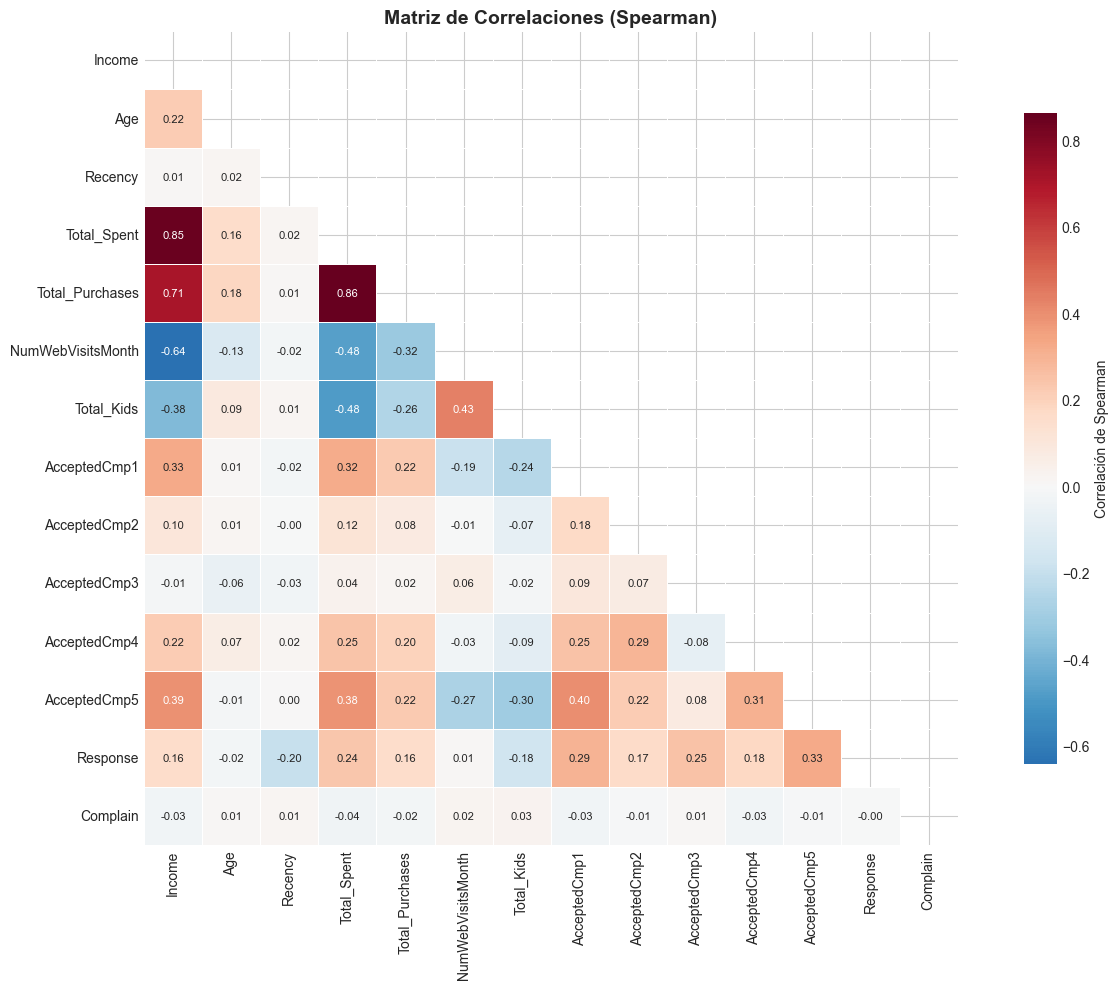

In [89]:
corr_matrix = dataset[all_numeric].corr(method='spearman')
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Máscara triangular
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True, linewidths=0.5,cbar_kws={"shrink": 0.8, "label": "Correlación de Spearman"},annot_kws={"size": 8})
plt.title('Matriz de Correlaciones (Spearman)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Se visualiza una alta correlación en las siguientes variables:

- **Total_Purchases & Total_Spent:** 0.86, clientes con más compras gastan más.

- **Total_Spent & Income:** 0.85, clientes con más ingresos gastan más.

- **Total_Purchases & Income:** 0.71, los clientes con mayor income tienen más compras realizadas.

- **Income & NumWebVisitsMonth:** -0.642, a mayor visitas en la web mensual, menor income.

Teniendo en cuenta que se encontró una alta correlación entre Total_Purchases & Total_Spent y Total_Spent & Income decido eliminar Total_Purechases ya que está altamente correlacionado con Total_Spent, y Total_Spent es una variable que aporta información más valiosa y mantener ambas introduciría ruido al clustering.

Así también optamos por eliminar Z_CostContact y Z_Revenue ya que son constantes y no aportan valor, ID que es un identificador y Complain ya que está muy desbalanceado.

Como se ha visto ls alta correlación entre Income y Total_Spent, apesar de que Income tiene un valor agregado propio este se solapa con Total_Spent, entonces he decidido dejar solo la variable de Total_Spent para que la muestra sea más significativa, también me he dado cuenta que la variable Recency no tiene un valor agregado tan importante por eso he decidido eliminarla también.


Y finalmente los features pre-seleccionados son los siguientes:

In [1010]:
features_pre_selected = ['Total_Kids','Total_Spent','NumWebVisitsMonth','Total_Accepted_Cmp']

Finalmente realizamos nuevamente la correlación de spearman y graficamos.

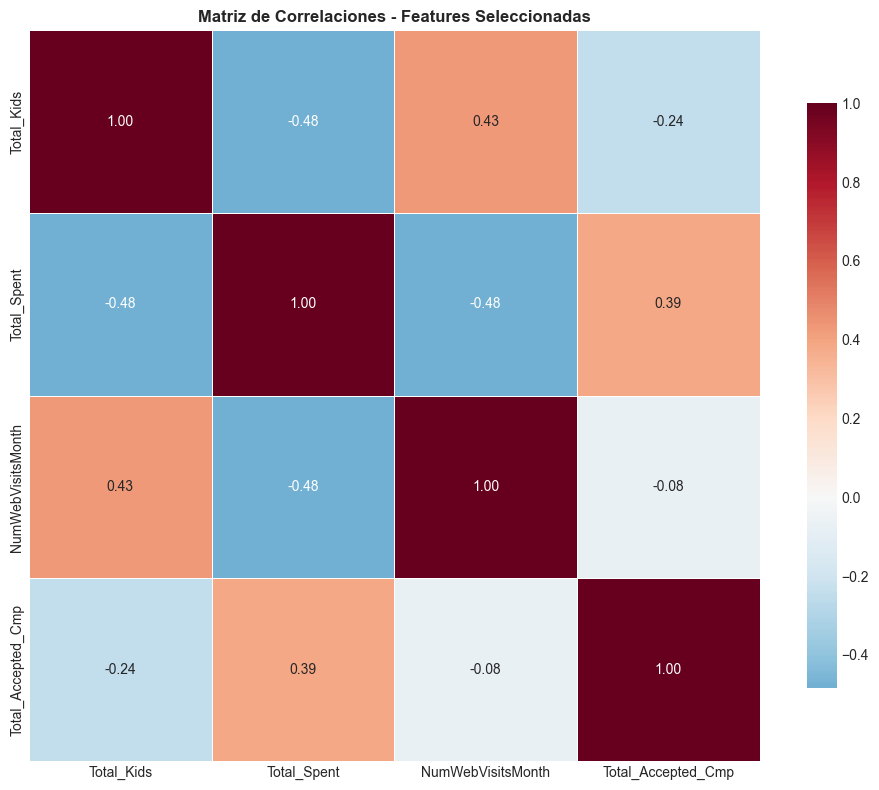

In [1011]:
corr_final = dataset[features_pre_selected].corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(corr_final, annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlaciones - Features Seleccionadas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


La matriz de correlación nos queda de la siguiente forma, no se observa colinealidad entre las variables y se visualiza como NumWebVisitsMonth y Total_Accepted_Cmp tienen comportamientos independiente entre si por lo tanto se podrían complementar.

### 2.2 PCA (Principal Component Analysis)

Para continuar con el análisis y el objetivo final de este trabajo que es identificar los grupos de clientes, primero hay que identificar cuales son componentes que realmente influyen en estos grupos. Para esto utilizamos PCA para hacer el análisis de componentes principales, el cual nos ayudará a reducir las dimensiones, a eliminar redundancia(si es que tenemos variables muy correlacionadas), a facilitar la visualizacion y mejorar el rendimiento del clustering.

In [1012]:
X = dataset[features_pre_selected].copy()

Antes de aplicar PCA estandarizamos los datos para que todas las variables se encuentren en la misma escala, ya que el PCA es sensible a las unidades de medida. Para ello utilizamos RobustScaler que es más robusto a los outliers ya que utiliza la mediana y el IQR en vez de la media y la mediana para la transformación de los datos.

In [1013]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features_pre_selected)

Luego se aplica el PCA a los datos estandarizados.

In [1014]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

Hallamos la varianza explicada y la varianza acumulativa.

In [1015]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

Graficamos la varianza explicada, la varianza acumulativa y el gráfico del codo.

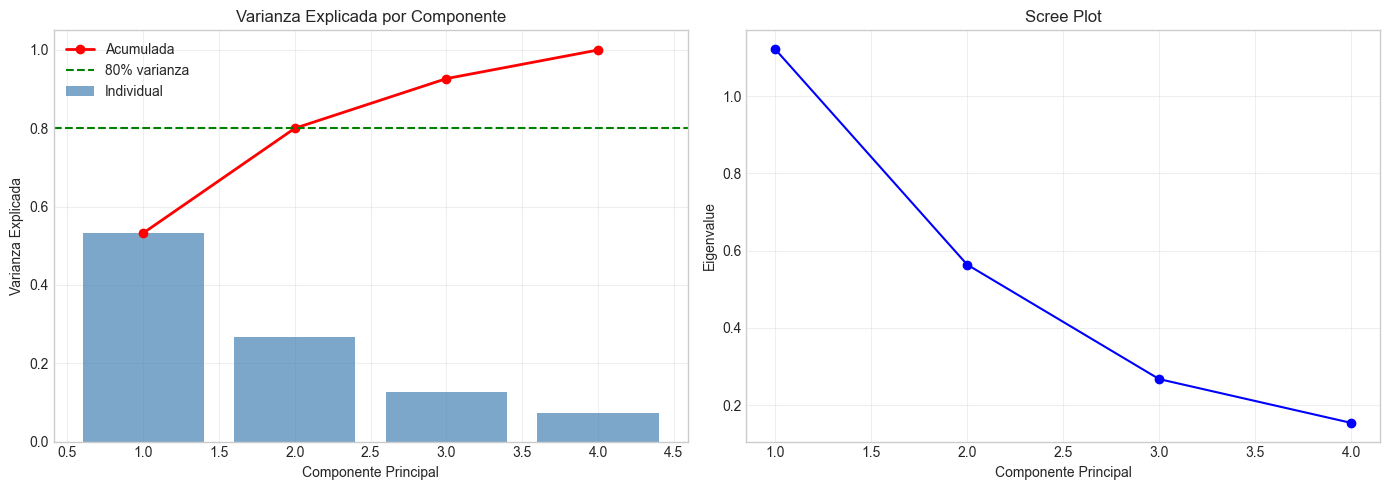

In [1016]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#Varianza explicada y varianza acumulativa
axes[0].bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.7, label='Individual', color='steelblue')
axes[0].plot(range(1, len(explained_variance)+1), cumulative_variance, 'ro-', label='Acumulada', linewidth=2)
axes[0].axhline(y=0.80, color='g', linestyle='--', label='80% varianza')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada')
axes[0].set_title('Varianza Explicada por Componente')
axes[0].legend()
axes[0].grid(alpha=0.3)

#Scree plot
axes[1].plot(range(1, len(explained_variance)+1), pca.explained_variance_, 'bo-')
axes[1].set_xlabel('Componente Principal')
axes[1].set_ylabel('Eigenvalue')
axes[1].set_title('Scree Plot')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

En el gráfico de la varianza explicada se visualiza la información que captura cada componente principal y cuanta varianza acumulada se logra al incluir componentes adicionales. En el gráfico de la izquierda se visualiza como el PC1 explica más del 50% de la varianza total el PC2 más del 20% y así sucesivamente. Lo que hay que tener en cuenta es que el PC1 captura más de la mitad de la variabilidad total y los tres primeros componentes juntos explican más del 80% de la varianza total.

Es por ello que seleccionaremos los componentes que expliquen más del 80% de la varianza.

In [1017]:
n_components = np.argmax(cumulative_variance >= 0.80) + 1
print(f"\nComponentes necesarios para 80% de varianza: {n_components}")
print(f"Varianza explicada por {n_components} componentes: {cumulative_variance[n_components-1]*100:.2f}%")


Componentes necesarios para 80% de varianza: 2
Varianza explicada por 2 componentes: 80.01%


Tres componentes logran explicar 80.01% de la varianza. Por lo tanto se seleccionan esos tres componentes para hacer el PCA.

In [1018]:
pca_final = PCA(n_components=n_components)
X_pca_final = pca_final.fit_transform(X_scaled)
print(f"\nDimensiones originales: {X_scaled.shape}")
print(f"Dimensiones después de PCA: {X_pca_final.shape}")


Dimensiones originales: (2240, 4)
Dimensiones después de PCA: (2240, 2)


Finalmente visualizamos los loadings que muestra la contribución de cada variable a cada componente principal. Que permite interpretar que representa cada PCA en terminos de las variables originales.

In [1019]:
loadings = pd.DataFrame(pca_final.components_.T, columns=[f'PC{i+1}' for i in range(n_components)],index=features_pre_selected)
display(loadings.round(3))

,PC1,PC2
Total_Kids,-0.499,0.541
Total_Spent,0.458,-0.159
NumWebVisitsMonth,-0.302,0.430
Total_Accepted_Cmp,0.671,0.705


**PC1:** las variables que mas contribuyen son el Total_Accepted_Cmp y Total_Spent que son variables relacionadas al consumo y a las campañas aceptadas.

**PC2:** las variables que mas contribuyen son el Total_Accepted_Cmp y Total_Kids que son variables relacionadas a la aceptación de campaña y la cantidad de hijos.

Las cuales resumen bastante bien las dimensiones principales del dataset y también eliminan la redundancia entre las variables correlacionadas manteniendo un 80.01% de la varianza explicada.

## 3. Clustering

### 3.1 Agrupación jerárquica

Para evaluar el modelo vamos a utilizar los siguientes métodos: <br><br>

- **Silhouette Distance:** esta métrica evalúa como un modelo ha sido capaz de diferenciar los clusters en función de la cercanía que tiene un dato con su cluster en comparación al siguiente clúster más cercano.
    - Si el punto está más cerca de su cluster que de otro cluster, el modelo ha separado bien los datos (Resultado ~ 1).
    - Si el punto está entre medio de dos clusters, el modelo no está seguro, los clusters se sobreponen (Resultado ~ 0).
    - Si el punto está más cerca de otro cluster que de su propio cluster, el modelo ha separado mal los datos (Resultado ~ -1).

    El resultado del test oscila entre -1 y 1.

<br>

- **Davies-Bouldin:** evalúa cómo de compactos son los clústeres ($S_i$ y $S_j$) y como de separados entre ellos están ($M_{ij}$).

    - Resultado ~ 0: los clústeres están bien separados y son compactos (bueno).
    - Cuanto mayor es el valor, peor es la calidad del Clustering, indicando clústeres con datos más dispersos y/o clústeres más cercanos entre sí (malo).
    
    El resultado del test oscila entre 0 y ∞.

<br>

- **Dendograma:** gráfico de árbol que muestra las agrupaciones hechas por el modelo.

<br>

- **Comparación de labels con predicciones:** los modelos de clustering son <u>no supervisados</u> pero el dataset contiene los labels reales de las categorías. Para saber si se está haciendo una agrupación correcta vamos a comparar los labels del árbol jerárquico con los labels reales.

<br><br>



Teniendo en cuenta esto iniciamos con los resultados finales obtenidos del PCA y aplicamos el clustering jerárquico.

In [1020]:
jerarquic = hierarchy.linkage(X_pca_final, method="ward", metric="euclidean")

Luego probamos distintas distancias y seleccionamos la más óptima según el Silhouette distance y Davies-Bouldin.

In [1021]:
distance_thresholds = np.linspace(0, 30, 10)
optimization_results = []
for threshold in distance_thresholds:
    clusters = fcluster(jerarquic, t=threshold, criterion='distance')
    n_clusters = len(np.unique(clusters))
    if n_clusters > 1 and n_clusters < len(X_pca_final):
        sil = silhouette_score(X_pca_final, clusters)
        db = davies_bouldin_score(X_pca_final, clusters)
    else:
        sil = -1
        db = np.inf
        ch = 0
    optimization_results.append({'Umbral': threshold,'N° Clusters': n_clusters,'Silhouette': sil,'Davies-Bouldin': db,})
df_optimization = pd.DataFrame(optimization_results)
print(df_optimization.head(15))

      Umbral  N° Clusters  Silhouette  Davies-Bouldin
0   0.000000         1901    0.276339    8.557887e-07
1   3.333333           22    0.474471    6.407163e-01
2   6.666667           14    0.512643    6.444005e-01
3  10.000000            9    0.518376    7.148371e-01
4  13.333333            7    0.481661    7.000023e-01
5  16.666667            5    0.475165    7.016770e-01
6  20.000000            5    0.475165    7.016770e-01
7  23.333333            5    0.475165    7.016770e-01
8  26.666667            4    0.450635    7.764319e-01
9  30.000000            3    0.409333    8.453271e-01


Graficamos el dendrograma con el que visualizaremos a justaremos la distancia de los clusters para tener los mejores scores.

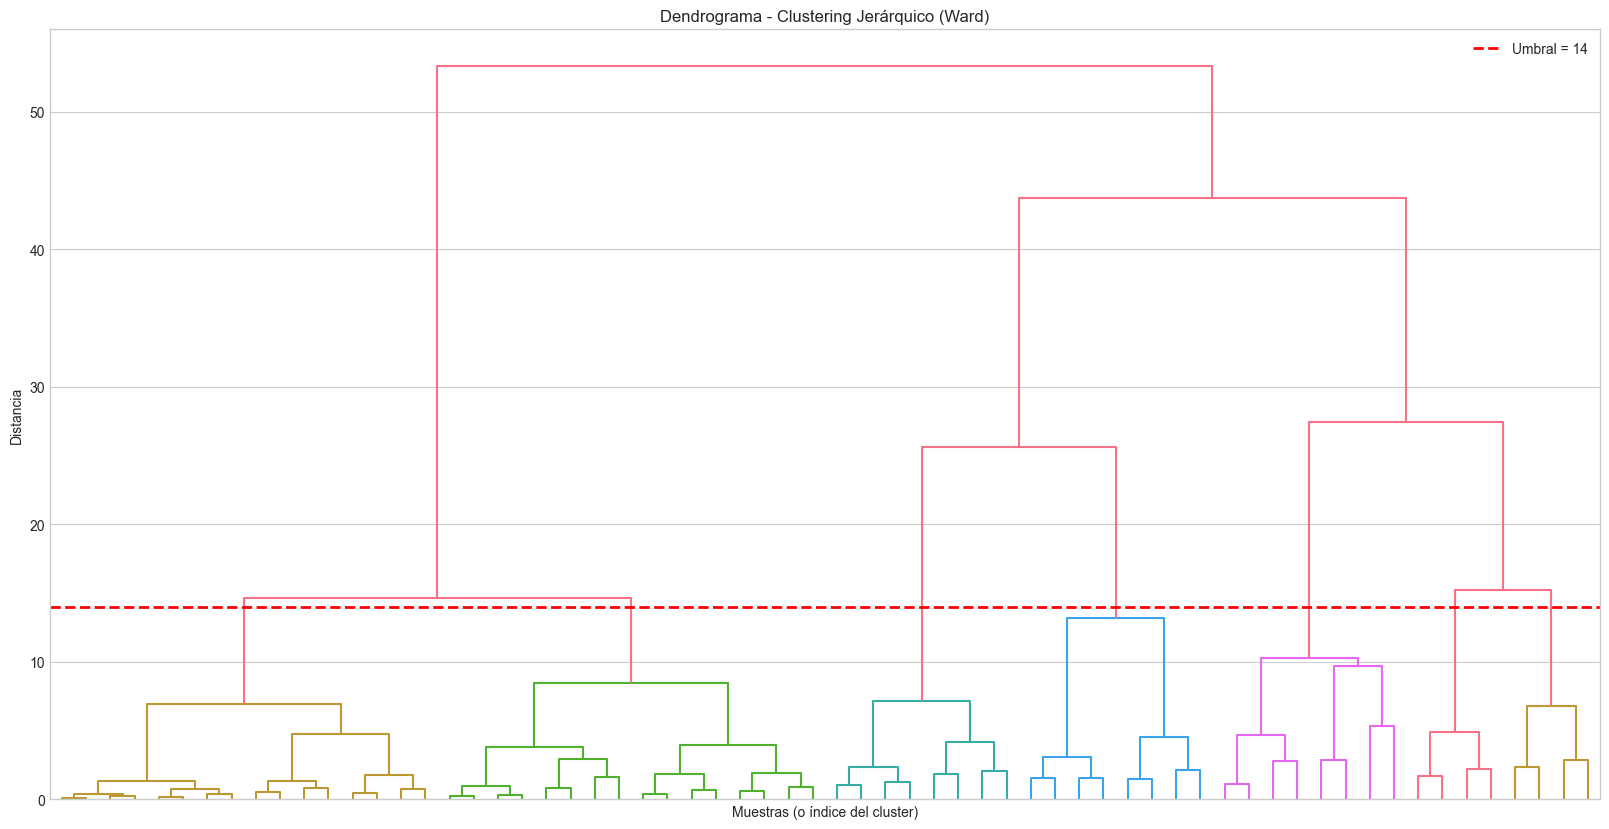

In [1022]:
plt.figure(figsize=(20, 10))
cluster_distance = 14
jerarquic_tree = hierarchy.dendrogram(jerarquic, color_threshold=cluster_distance,no_labels=True,truncate_mode='level',p=5)
plt.axhline(y=cluster_distance, color='r', linestyle='--', linewidth=2, label=f'Umbral = {cluster_distance}')
plt.xlabel('Muestras (o índice del cluster)')
plt.ylabel('Distancia')
plt.title('Dendrograma - Clustering Jerárquico (Ward)')
plt.legend()
plt.show()

Obtenemos los labels del clustering.

In [1023]:
cluster_labels_hier = fcluster(jerarquic, t=cluster_distance, criterion="distance")
dataset['Cluster_Hier'] = cluster_labels_hier
print(f"Clusters únicos: {len(dataset['Cluster_Hier'].unique())}")

Clusters únicos: 7


Evaluamos con Silhouette Score.

In [1024]:
sil_score_hier = silhouette_score(X_pca_final, cluster_labels_hier)
db_score_hier = davies_bouldin_score(X_pca_final, cluster_labels_hier)
print(f"\nSilhouette Score: {sil_score_hier:.4f}")
print(f"Davies-Bouldin Score: {db_score_hier:.4f}")


Silhouette Score: 0.4817
Davies-Bouldin Score: 0.7000


**Silhouette Distance:** 0.4817, está mas cerca de 0 que de 1 por lo tanto el modelo no ha separado bien los datos, el modelo está mas cerca de 0, quizás algunos clusters se sobrepongan.

**Davies-Bouldin:** 0.7000, la calidad del clustering no es la mejor, los clústers estan cerca entre sí.


Visualizamos los clusters en las dos primeras componentes principales.

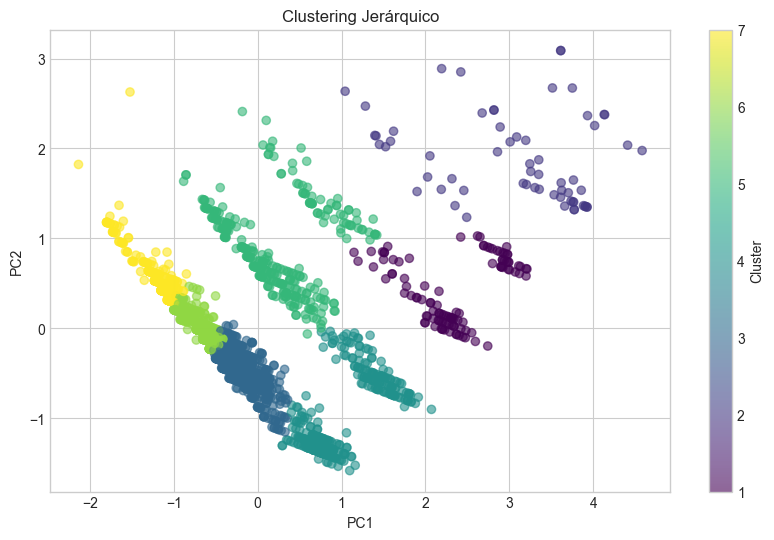

In [1025]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca_final[:, 0], X_pca_final[:, 1], c=dataset['Cluster_Hier'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clustering Jerárquico')
plt.show()

Donde se comprueba que el modelo no es capaz de separar bien los clústers entre sí. El resultado obtenido es moderado, no óptimo podría ser aceptable considerando que los datos de los clientes rara vez tienen separaciones perfectas. Apesar de ello seguiremos intentando mejorar los resultados útilizando otros algoritmos.

### 3.2 K-Means

K-means es un algoritmo de clustering que divide los datos en K grupos, es decir clusters, donde cada cluster tiene un centroide (punto central) que asigna a cada observación al centroide más cercano.

##### **3.2.1 Método del codo**

Para determinar el número óptimo de clusters se utilizó el método del codo, evaluando 
valores de k entre 2 y 11 y se aplico el algoritmo de K-means para el rango de valores dado con el objetivo de segmentar a los clientes en grupos homogéneos.

In [1026]:
min_clusters = 2
max_clusters = 11
kmeans_model_list = [KMeans(n_clusters=k, random_state=42, n_init=11).fit(X_pca_final) for k in range(min_clusters, max_clusters)]

Luego guardamos las inercias y silhouette scores.

In [1027]:
inertias = [model.inertia_ for model in kmeans_model_list]
silhouettes = [silhouette_score(X_pca_final, model.labels_) for model in kmeans_model_list]

Luego visualizamos el método del codo y silhouette.

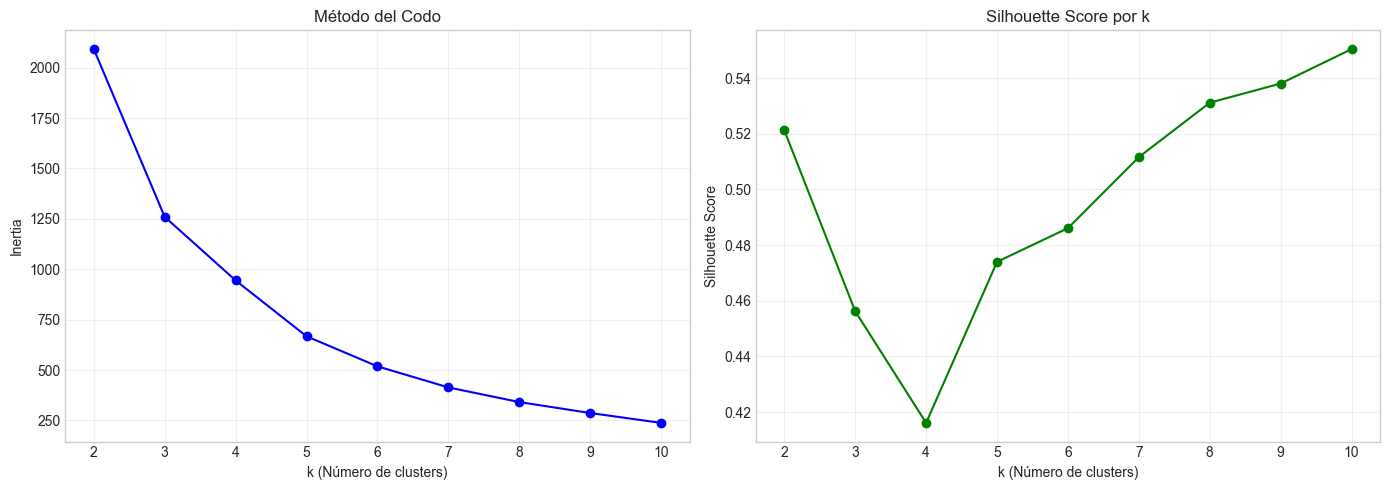

In [1028]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(min_clusters, max_clusters), inertias, "bo-")  #Método del codo
axes[0].set_xlabel("k (Número de clusters)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Método del Codo")
axes[0].grid(alpha=0.3)

axes[1].plot(range(min_clusters, max_clusters), silhouettes, "go-")  #Silhouette score
axes[1].set_xlabel("k (Número de clusters)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score por k")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

En la gráfica se visualiza que el codo podría estar entre 4 y 6. Hay una disonancia entre el método del codo y el score de silhouette probablemente los grupos presentan solapamiento.

##### **3.2.2 Entrenamiento del modelo**

Teniendo en cuenta los gráficos anteriores seleccionamos el k óptimo para este caso supongo 6.

In [1031]:
k_optimal = 6
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=50)
kmeans_final.fit(X_pca_final)
dataset['Cluster_KMeans'] = kmeans_final.labels_

Y evaluamos sus scores.

In [1032]:
sil_score_kmeans = silhouette_score(X_pca_final, dataset['Cluster_KMeans'])
db_score_kmeans = davies_bouldin_score(X_pca_final, dataset['Cluster_KMeans'])
print(f"K-Means con k={k_optimal}")
print(f"Silhouette Score: {sil_score_kmeans:.4f}")
print(f"Davies-Bouldin Score: {db_score_kmeans:.4f}")

K-Means con k=6
Silhouette Score: 0.4858
Davies-Bouldin Score: 0.6714


**Silhouette Distance:** 0.4858, está mas cerca de 0 que de 1 por lo tanto el modelo no ha separado bien los datos, el modelo está mas cerca de 0, hay una probabilidad que los clusters se sobrepongan.

**Davies-Bouldin:** 0.6714, la calidad del clustering es moderada, digamos que se podría compensar si el score de Silhoutte salía mejor pero para este algorimo no parece apropiado.

Visualizamos los clústers.

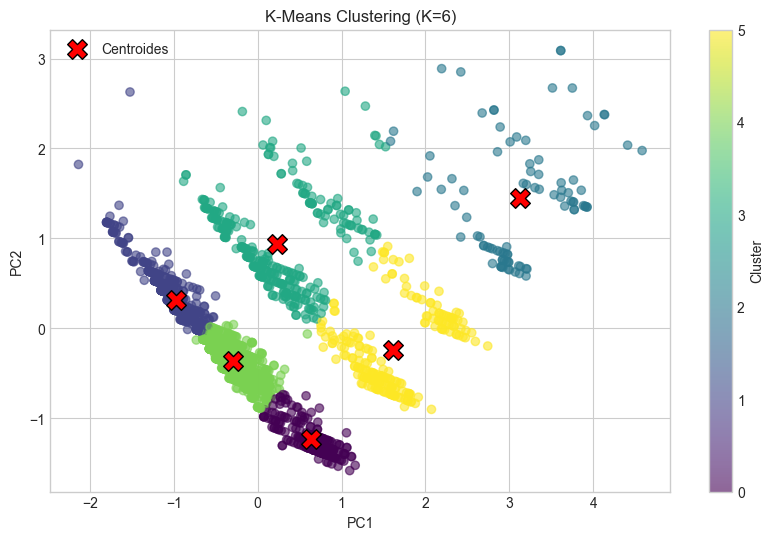

In [1033]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca_final[:, 0], X_pca_final[:, 1], c=dataset['Cluster_KMeans'], cmap='viridis', alpha=0.6)
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1], c='red', marker='X', s=200, edgecolors='black', label='Centroides')
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-Means Clustering (K={k_optimal})')
plt.legend()
plt.show()

El algoritmo de K-means clusterizo los datos pero no de manera adecuada, que se alinea a los valores de Silhouette Distance de 0.4858 y Davies-Bouldin de 0.6714 ya que los clusters no están bien separados y se sobreponen entre si. Es por esto que probaremos con DBSCAN que utiliza otro algoritmo para agrupar los datos.

### 3.3 DBSCAN

DBSCAN es un algoritmo de aprendizaje no supervisado que agrupa los datos basándose en la densidad de las muestras. A diferencia de los algoritmos de clustering basado en centroides,DBSCAN no asume que los clústeres sean circulares. Es muy resistente a outliers.
No hace falta configurar un parámetro $k$, pero si que hace falta configurar los parámetros eps (esfera de influencia de los nodos) y MinPts (cantidad de muestras que debe tener un nodo en su área eps para que se considere core). 

##### **3.3.1 Encontrar eps óptimo con k-distance graph**

Utilizamos KNN para buscar las distancias entre los nodos, luego lo representamos en un plot para aplicar el criterio del codo y así encontrar el valor de eps para la distancia deseada.

In [1034]:
min_samples = 2 * n_components
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_pca_final)
distances, indices = neighbors_fit.kneighbors(X_pca_final)

Ordenamos las distancias a k-ésimo vecino.

In [1035]:
dist_kth = np.sort(distances[:, min_samples-1], axis=0)

Y graficamos k-distance para encontrar eps.

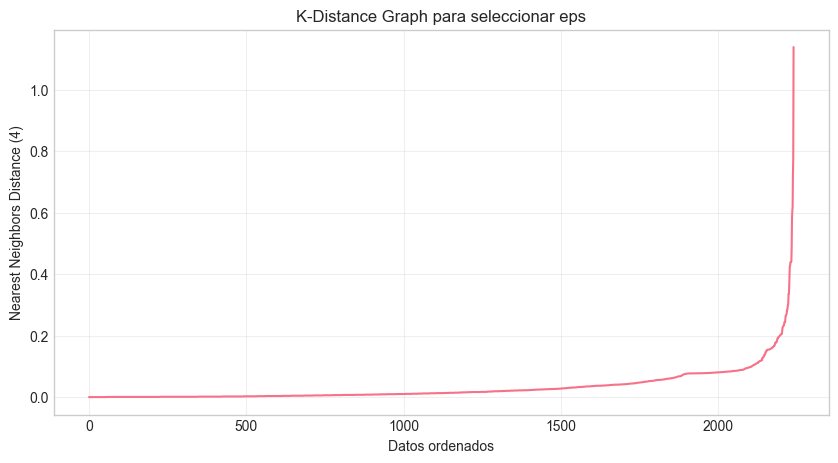

In [1036]:
plt.figure(figsize=(10, 5))
plt.plot(dist_kth)
plt.xlabel("Datos ordenados")
plt.ylabel(f"Nearest Neighbors Distance ({min_samples})")
plt.title("K-Distance Graph para seleccionar eps")
plt.grid(alpha=0.3)
plt.show()

Hacemos un zoom en el codo del grafico y marcamos posibles valores de eps.

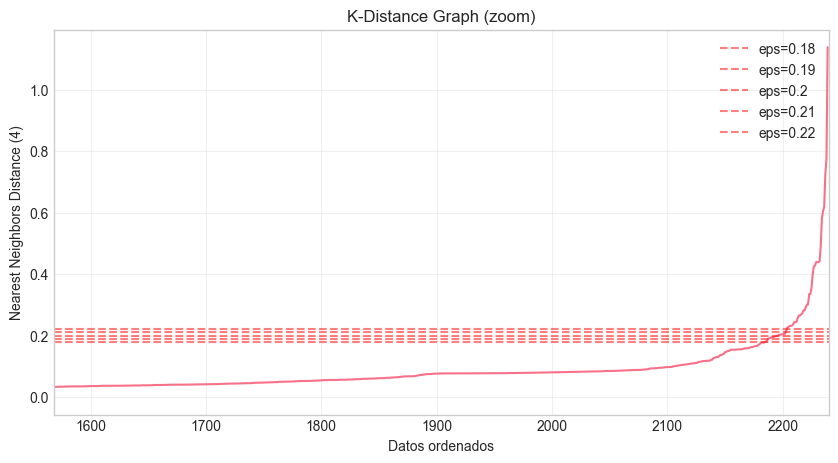

In [1037]:
plt.figure(figsize=(10, 5))
plt.plot(dist_kth)
plt.xlim(len(dist_kth)*0.7, len(dist_kth))
plt.xlabel("Datos ordenados")
plt.ylabel(f"Nearest Neighbors Distance ({min_samples})")
plt.title("K-Distance Graph (zoom)")

eps_candidates = [0.18, 0.19, 0.2, 0.21, 0.22]  #posibles valores de eps
for eps in eps_candidates:
    plt.axhline(y=eps, color='r', linestyle='--', alpha=0.5, label=f'eps={eps}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Con este gráfico fui haciendo pruebas entorno al valor del codo ya que ese es el punto donde cambia la velocidad de crecimiento de las distancias. Y a continuación le entrené con el modelo DBSCAN.

##### **3.3.2 Entrenamiento del modelo DBSCAN**

Según el grafico de K-distance elegí el eps, que también lo fui ajustando y probando.

In [1038]:
eps_value = 0.47 
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples)
dataset['Cluster_DBSCAN'] = dbscan.fit_predict(X_pca_final)

In [1039]:
n_clusters_dbscan = len(set(dataset['Cluster_DBSCAN'])) - (1 if -1 in dataset['Cluster_DBSCAN'].values else 0)
n_noise = (dataset['Cluster_DBSCAN'] == -1).sum()
print(f"DBSCAN (eps={eps_value}, min_samples={min_samples})")
print(f"Clusters encontrados: {n_clusters_dbscan}")
print(f"Puntos de ruido: {n_noise} ({n_noise/len(dataset)*100:.2f}%)")

DBSCAN (eps=0.47, min_samples=4)
Clusters encontrados: 7
Puntos de ruido: 4 (0.18%)


El punto donde había menos ruido y clusterizaba bien.

In [1040]:
mask = dataset['Cluster_DBSCAN'] != -1
if mask.sum() > 0 and n_clusters_dbscan > 1:
    sil_score_dbscan = silhouette_score(X_pca_final[mask], dataset.loc[mask, 'Cluster_DBSCAN'])
    db_score_dbscan = davies_bouldin_score(X_pca_final[mask], dataset.loc[mask, 'Cluster_DBSCAN'])
    print(f"\nSilhouette Score (sin ruido): {sil_score_dbscan:.4f}")
    print(f"Davies-Bouldin Score (sin ruido): {db_score_dbscan:.4f}")
else:
    print("\nNo se pueden calcular métricas: muy pocos clusters o muchos puntos de ruido")


Silhouette Score (sin ruido): 0.3586
Davies-Bouldin Score (sin ruido): 1.1991


Los scores para Silhouette Distance y Davies-Bouldin son moderados, podrían representar bien a los grupos.

Luego visualicé los clusters con DBSCAN.

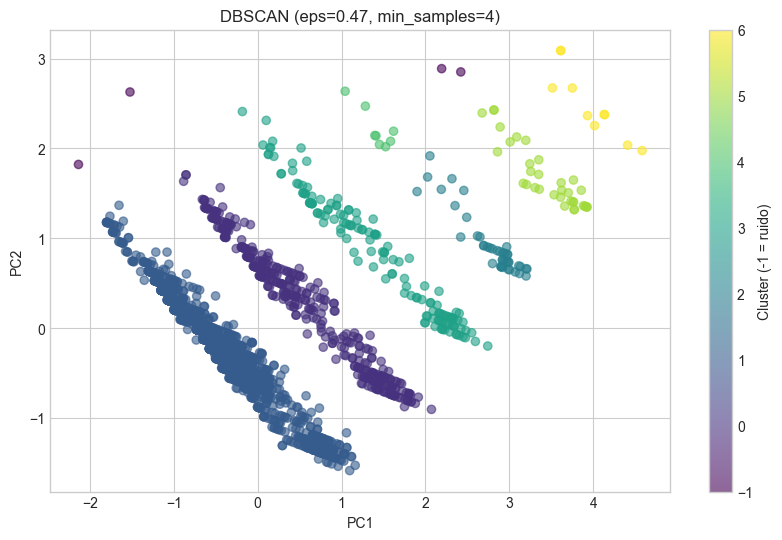

In [1042]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca_final[:, 0], X_pca_final[:, 1], c=dataset['Cluster_DBSCAN'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster (-1 = ruido)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'DBSCAN (eps={eps_value}, min_samples={min_samples})')
plt.show()

Se observa que el algoritmo DBSCAN con parámetros eps=0.47 y min_samples=4 ha identificado 7 grupos distintos los cuales parecencen estar bien clusterizados, estan separados en grupos, dos de ellos presentan ruido. Pero en esta imagen se visualiza como el algoritmo de DBSCAN logra capturar mejor la estructura diagonal y de densidad variable de los datos, así también es más robusto a outliers que podrían distorsionar los clusters.

## 4. Justificación de decisiones

Este estudio inicio con el análisis exploratorio de los datos, donde se encontraron 24 nulls en la variable Income a los cuales se les relleno con la mediana por grupo significativo, en este caso por nivel de estudios y si hay niños en el hogar.

Luego se evaluaron todas las distribuciones donde se encontraron outliers, y se concluyó que ninguna variable continua tenia una distribución normal mediante el test de Shapiro-Wilk. Esto fue fundamental para la parte del procesado inicial de los datos donde se realizó el análisis de la correlación descartando variables redundantes y seleccionando para el análisis Total_Kids, Total_Spent, NumWebVisitsMonth y Total_Accepted_Cmp. Estas variables representan comportamiento de compra y engagement del cliente, siendo más relevantes que características demográficas para estrategias de marketing.

La detección de outliers fue fundamental para tomar la decisión de utilizar el RobustScaler para el escalado de los datos, ya que este es más robusto a valores extremos. Luego se aplicó el PCA reteniendo un 80.01% alto de varianza explicada, lo cual permitió reducir dimensionalidad y ruido en los datos.

Finalmente se aplicaron tres algoritmos de clustering con resultados diferentes. El clustering jerárquico obtuvo las mejores métricas con Silhouette: 0.481661, con Davies-Bouldin: 0.700002 identificando 108 clusters, que es una cantidad excesiva y poco práctica para segmentación de clientes.

El algoritmo de K-Means identificó entre 6 clusters con métricas moderadas con Silhouette: 0.485754 y Davies-Bouldin: 0.671418, donde se visualizó solapamiento en los grupos debido a que asume clusters esféricos mientras los datos tienen formas irregulares. 

DBSCAN identificó 7 clusters con métricas con Silhouette: 0.358592 y  Davies-Bouldin: 1.199105 pero pudo detectar la forma irregular de los datos y los outliers automáticamente.

In [ ]:
results = pd.DataFrame({
    'Método': ['Jerárquico', 'K-Means', 'DBSCAN'],
    'N° Clusters': [len(dataset['Cluster_Hier'].unique()),len(dataset['Cluster_KMeans'].unique()),n_clusters_dbscan],
    'Silhouette Score': [sil_score_hier, sil_score_kmeans,  sil_score_dbscan if 'sil_score_dbscan' in locals() else None],
    'Davies-Bouldin': [db_score_hier, db_score_kmeans,db_score_dbscan if 'db_score_dbscan' in locals() else None]})
display(results)

,Método,N° Clusters,Silhouette Score,Davies-Bouldin
0,Jerárquico,7,0.481661,0.700002
1,K-Means,6,0.485754,0.671418
2,DBSCAN,7,0.358592,1.199105


Por esa razón se decide utilizar a DBSCAN como el algoritmo para implementar en producción por su flexibilidad para detectar formas irregulares y outliers automáticamente.

Finalmente los clusters creados son los siguientes.

In [1050]:
cluster_profile = dataset.groupby('Cluster_DBSCAN')[features_pre_selected].median()
display(cluster_profile.round(2))

,Total_Kids,Total_Spent,NumWebVisitsMonth,Total_Accepted_Cmp
Cluster_DBSCAN,,,,
-1,2.0,446.5,14.0,2.5
0,1.0,789.0,6.0,1.0
1,1.0,234.0,6.0,0.0
2,0.0,1650.0,3.0,3.0
3,1.0,1184.5,6.0,2.0
4,1.0,626.0,7.5,3.0
5,0.0,1723.5,2.5,4.0
6,0.0,1682.0,4.0,5.0


Visualizamos el perfil normalizado.

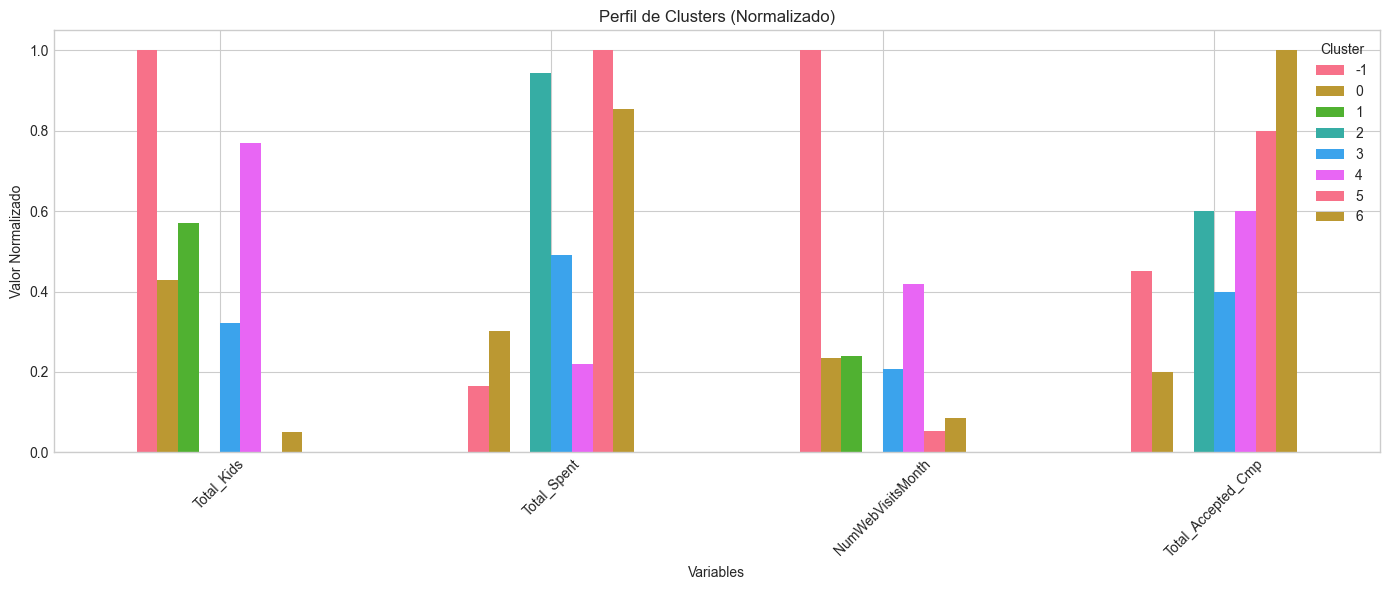

In [1049]:
cluster_profile_normalized = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())
cluster_profile_normalized.T.plot(kind='bar', figsize=(14, 6))
plt.title('Perfil de Clusters (Normalizado)')
plt.xlabel('Variables')
plt.ylabel('Valor Normalizado')
plt.legend(title='Cluster')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se observa que el algoritmo de DBSCAN ha identificado 8 grupos diferentes de clusters -1 a 6, donde -1 representa outliers:

- **Clusters 2, 5 y 6 (Clientes Premium):** muy pocos hijos, gasto muy alto, bajo engagement web y altísima aceptación a las campañas. 

- **Clusters 0 y 3 (Segmento Intermedio):** cantidad moderada de hijos, gasto medio-alto y aceptación de campañas moderada.

- **Cluster 1 (Familias de Bajo Valor):** familias con hijos más que el promedio, bajo gasto y sin aceptar campañas.

- **Cluster 4 (Familias con Alto Engagement):** familias con muchos hijos, con gasto moderado, alto engagement web y buena aceptación a las campañas.

- **Cluster -1 (Outliers):** representa un comportamiento atípico con el mayor número de visitas web y gasto moderado.

Con esto se recomienda implementar estrategias de marketing diferenciadas según perfil: fidelización para clientes premium, promociones familiares para familias numerosas, conversión digital para clientes exploradores y reactivación para los clientes que tienen bajo engagement. 

## 5. Conclusiones

En este estudio se realizó un análisis exploratorio del dataset customer_data.csv para entender el perfil de los clientes de La Vía Láctea y realizar una segmentación de los mismos utilizando técnicas de clustering para abordar estratégicamente una campaña de marketing.

Para ello primero se realizó un análisis exhaustivo de las variables numéricas y categóricas, se verificaron los valores nulos, se analizaron las distribuciones de las variables y sus outliers. Se realizí un procesado inicial de los datos donde se correlacionaron las variables que aportan valor al análisis para entender si existe colinealidad de forma a que no influya en el clustering. Mediante la correlación se descartan las variables altamente correlacionadas y las que no aportan valor al análisis y luego se realizó la técnica del PCA para reducción de dimensionalidad donde se tuvo que escalar utilizando RobustScaler para evitar que los outliers distorsionen la segmentación. Donde se seleccionaron 2 componentes que explican 80.01% de la varianza, manteniendo la mayor parte de la información relevante.

Luego, se realizó el clustering con tres enfoques diferentes el Jerárquico que generó una cantidad de grupos demasiado grande, lo cual resulto poco práctico para una estrategia real de segmentación. El algoritmo de K-Means que logró una separación aceptable, pero asume clusters más “esféricos” y no se adapta tan bien a formas irregulares ni a outliers.Y por último DBSCAN que es un algoritmo que identifica clusters con forma irregular y maneja outliers automáticamente, para este estudio con DBSCAN se obtuvieron clusters interpretables que permiten proponer una estrategia de campaña.

Los Clientes Premium (clusters 2, 5 y 6) tienen alto gasto y alta aceptación de campañas, así que son el target principal para campañas de fidelización y para ofrecerles productos o beneficios de mayor valor. El Segmento Intermedio (clusters 0 y 3) muestran gasto medio y respuesta moderada, por lo que conviene mantenerlos interesados con descuentos moderados, combos y mensajes, según el canal que mejor les funcione. Las Familias de Bajo Valor (cluster 1) tienen bajo gasto y baja aceptación, entonces no vale la pena invertir fuerte: mejor campañas de bajo costo y pruebas puntuales. Las Familias con Alto Engagement (cluster 4) interactúan mucho en la web y responden bien, ideal para campañas digitales más personalizadas. Y los outliers (cluster -1) conviene analizarlos aparte porque su comportamiento atípico puede esconder oportunidades.

En conclusión, la segmentación basada en DBSCAN y PCA nos permitió definir acciones concretas por tipo de cliente, optimizando nuestro presupuesto y aumentando la probabilidad de respuesta, enfocando la campaña donde realmente hay impacto, que son los clientes Premium y alto engagement. Lo cual nos permitió reducir esfuerzos donde no hay el retorno esperado.